<h3 style="text-align: center;"> <strong> UNIVERSIDAD TECNOLÓGICA DE PANAMÁ </strong></h3>
<h3 style="text-align: center;">FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
<h3 style="text-align: center;">DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
    
<h1 style="text-align: center;"><strong>-------LABORATORIO N°5:  Relaciones, Valores Faltantes e Imputación-------</strong></h1>
<h3 style="text-align: center;">ANÁLISIS DE DATOS Y TOMA DE DECISIONES PARA COMPUTACIÓN - 1195</h3>




|  **FACILITADOR** | Dr. José Carlos Rangel Ortiz          |
|-----------------|---------------------------------------|
| **MÓDULO 1**    | Introducción a la Ciencia de Datos    |
|  **UNIDAD 2**    | Minería de Datos       |
    

| **NOMBRE DEL ESTUDIANTE:** | ________________________________________________________________________________________|
|----------------------------|-----------------------------------------------------------------------------------------|

# **Introducción al laboratorio**

## **Relaciones en distribuciones de datos**
Encontrar relaciones entre variables es un proceso fundamental en la ciencia de datos. Las técnicas estadísticas y de aprendizaje automático, como la correlación, la regresión y el análisis de redes, se utilizan para descubrir estas relaciones, a menudo visualizando los datos de diversas maneras.
A medida que la cantidad y complejidad de los datos siguen creciendo, la importancia de encontrar relaciones entre variables seguirá aumentando. La capacidad de identificar estas relaciones será crucial para resolver problemas complejos, tomar decisiones informadas y avanzar en el conocimiento en diversos campos.

Encontrar relaciones entre los datos nos puede ayudar en aspectos como:
- Explicar Fenómenos
- Hacer Predicciones
- Tomar Decisiones Informadas



## **Valores Faltantes**
Los valores faltantes son un problema común en los conjuntos de datos del mundo real. Pueden deberse a diversas causas, como errores de entrada de datos, respuestas no proporcionadas en encuestas o la naturaleza misma del fenómeno que se está midiendo. Si no se abordan adecuadamente, los valores faltantes pueden tener un impacto significativo en los análisis de datos, lo que lleva a resultados sesgados e inexactos.

**¿Por qué es importante el manejo de valores faltantes?**
Existen varias razones por las que el manejo de valores faltantes es crucial en la ciencia de datos:
1. **Reduce el sesgo:** Cuando se ignoran los valores faltantes, se asume implícitamente que esos casos son similares a los casos completos. Esta suposición puede ser errónea y conducir a sesgos en los resultados del análisis.
2. **Aumenta la precisión:** La imputación de los valores faltantes puede aumentar la precisión de los análisis estadísticos al aumentar el tamaño de la muestra y reducir la variabilidad.
3. **Mejora la interpretabilidad:** Los modelos de aprendizaje automático pueden ser sensibles a la presencia de valores faltantes.
4. **Permite un análisis más completo:** Al tratar los valores faltantes, se puede utilizar toda la información disponible.

## **¿Qué es la imputación?**
La imputación es un proceso estadístico para estimar los valores faltantes en un conjunto de datos. Existen diversos métodos de imputación, cada uno con sus propias ventajas e inconvenientes. La elección del método de imputación adecuado depende del patrón de falta de datos, la naturaleza de las variables y el objetivo del análisis.

En resumen, el encontrar relaciones, el manejo de valores faltantes y la imputación son aspectos cruciales de la ciencia de datos. En este laboratorio se presentan operaciones para estos 3 aspectos de la ciencia de datos.

<div class="alert alert-success", role="alert">
    <h1 style="font-size: 1.5em;">Parte 1 </h1>
    <h2 style="font-size: 1.5em; "><strong>Distribuciones y Relaciones en los datos</strong></h2>
</div>

In [1]:
!pip install empiricaldist palmerpenguins pyjanitor statsmodels

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Importar librerías

In [2]:
import empiricaldist
import janitor
import matplotlib.pyplot as plt
import numpy as np
import palmerpenguins
import pandas as pd
import scipy.stats
import seaborn as sns
import sklearn.metrics
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats as ss

## Establecer apariencia general de los gráficos

In [3]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

## Cargar los datos

# Conociendo nuestros datos de pingüinos. 🗺🧭🐧

### Utilizando el paquete `palmerpenguins`

#### Datos crudos

In [4]:
preprocess_penguins_df = palmerpenguins.load_penguins()
preprocess_penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
process_penguins_df = (
    preprocess_penguins_df
    .dropna()
)
process_penguins_df.isnull().sum()
process_penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## **[1]** Presente un gráfico de conteo separado por Isla

/tmp/ipykernel_3524/4268199173.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=process_penguins_df, x='island', palette='Set2')


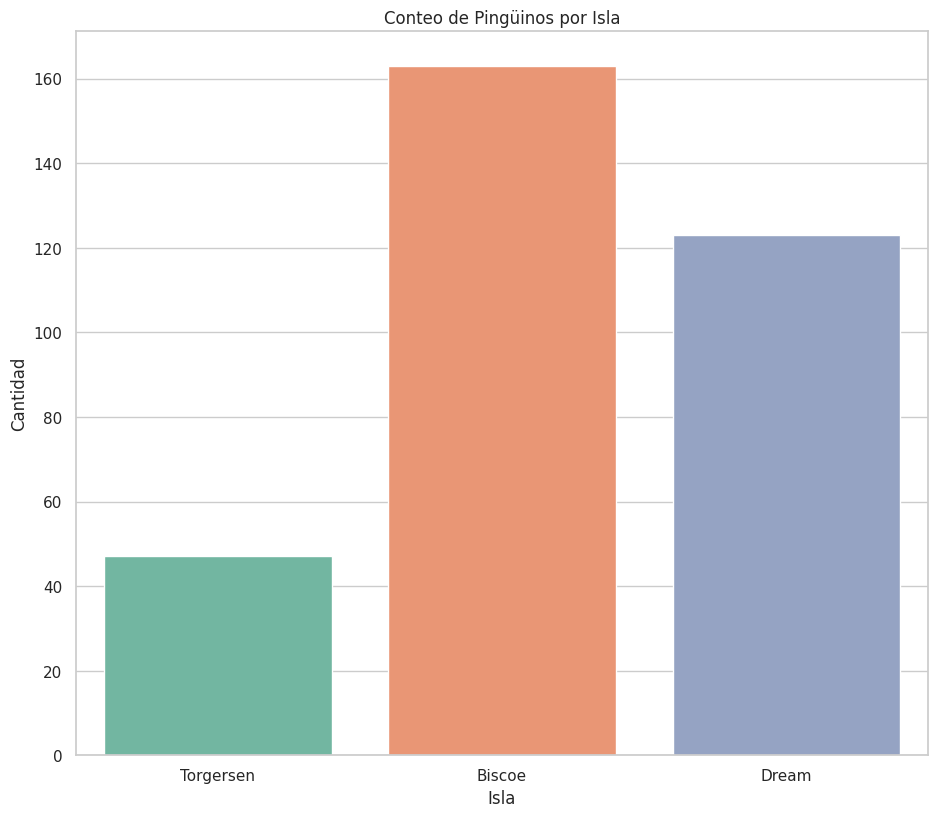

In [6]:
sns.countplot(data=process_penguins_df, x='island', palette='Set2')
plt.title('Conteo de Pingüinos por Isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad')
plt.show()

## **[2]** Presente un gráfico de conteo separado por Sexo

/tmp/ipykernel_3524/1376495590.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=process_penguins_df, x='sex', palette='Set2')


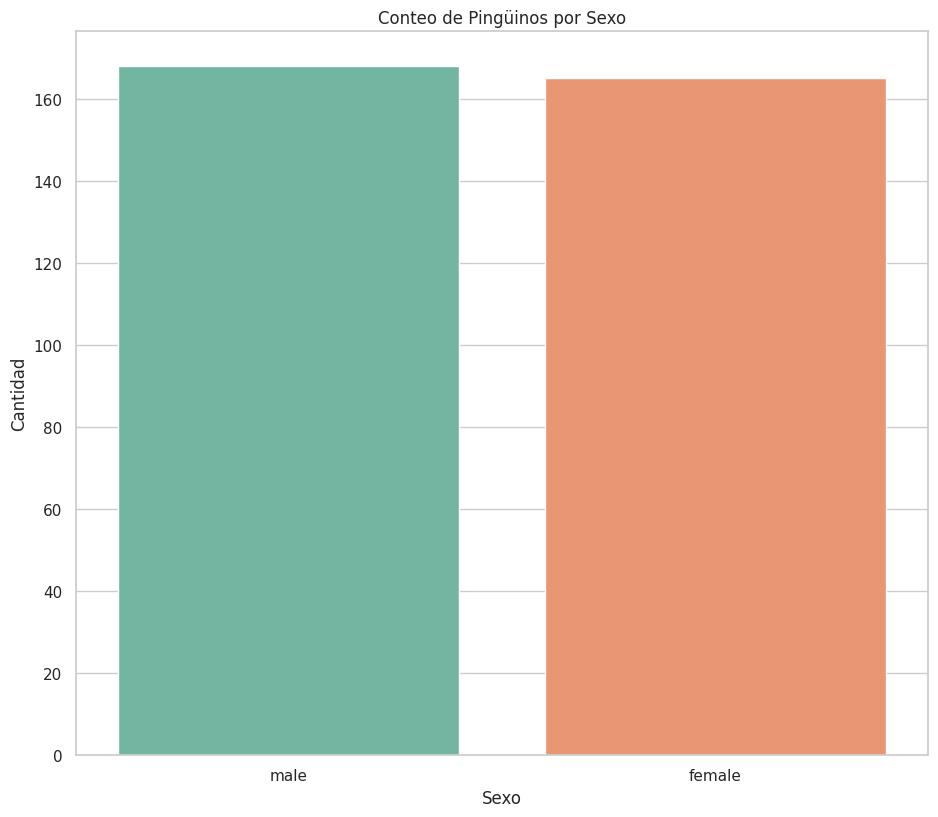

In [7]:
sns.countplot(data=process_penguins_df, x='sex', palette='Set2')
plt.title('Conteo de Pingüinos por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad')
plt.show()

## **[3]** Tomando como referencia el histograma [Ref P1.A] del archivo de ejemplos, repita el proceso para la variable *body_mass_g*, agrupado por *sex*.

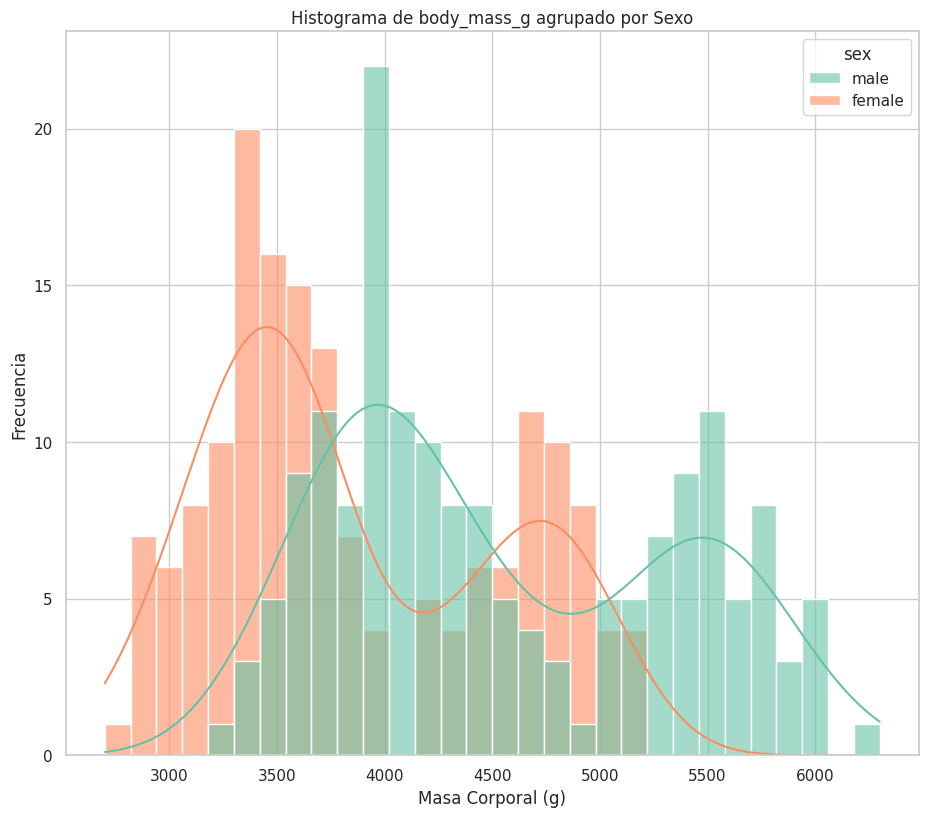

In [8]:
sns.histplot(data=process_penguins_df, x='body_mass_g', hue='sex', 
             bins=30, kde=True, palette='Set2', alpha=0.6)
plt.title('Histograma de body_mass_g agrupado por Sexo')
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Frecuencia')
plt.show()

## **[4]** Tomando en cuenta el gráfico [Ref P1.B] del archivo de ejemplos genere un JoinPlot comparando la variable *bill_length_mm* con *flipper_length_mm*, agrupando por especie

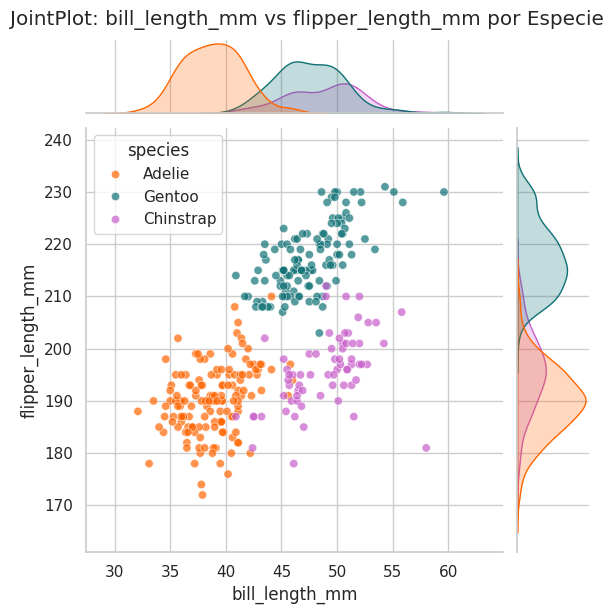

In [9]:
sns.jointplot(data=process_penguins_df, x='bill_length_mm', y='flipper_length_mm',
              hue='species', palette=penguin_color, alpha=0.7)
plt.suptitle('JointPlot: bill_length_mm vs flipper_length_mm por Especie', y=1.02)
plt.show()

## Funciones de probabilidad de masas (PMFs)

## **[5]** Hacer un pmf de bill_length_mm y obtener la probabilidad para 3 valores diferentes, presente la gráfica de la distribución

P(bill_length_mm = 35.0) = 0.0060
P(bill_length_mm = 42.0) = 0.0060
P(bill_length_mm = 50.0) = 0.0150


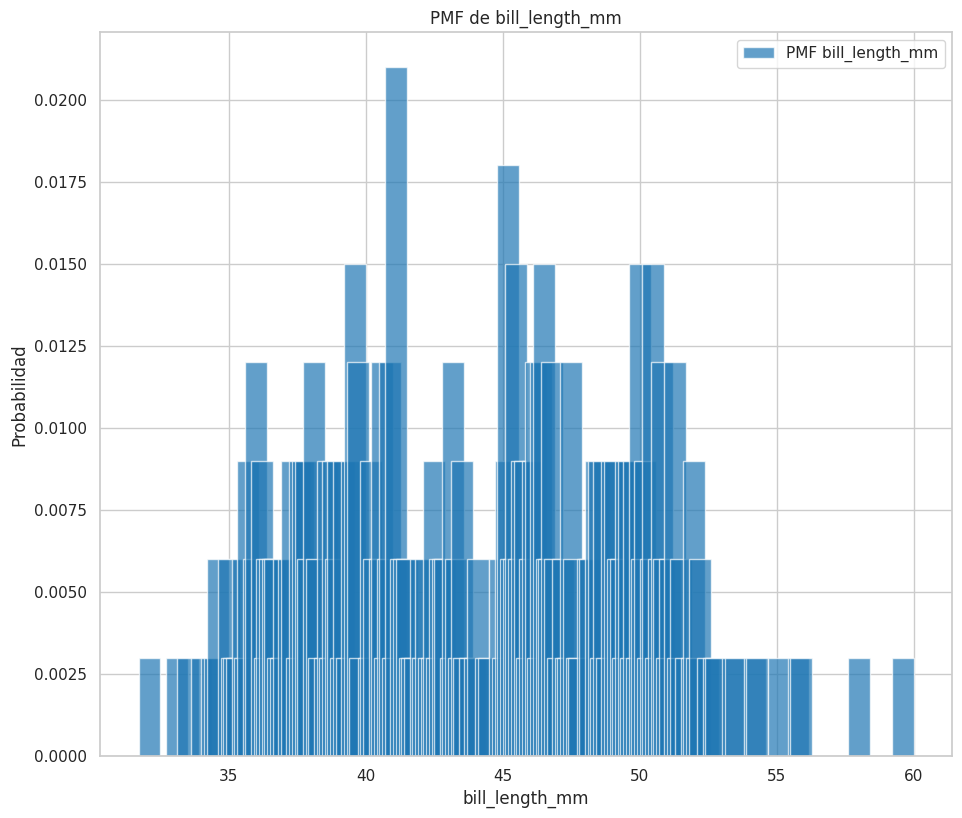

In [10]:
pmf_bill_length = empiricaldist.Pmf.from_seq(process_penguins_df['bill_length_mm'])

valores = [35.0, 42.0, 50.0]
for v in valores:
    prob = pmf_bill_length(v)
    print(f'P(bill_length_mm = {v}) = {prob:.4f}')

pmf_bill_length.bar(label='PMF bill_length_mm', alpha=0.7)
plt.title('PMF de bill_length_mm')
plt.xlabel('bill_length_mm')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

## Funciones empíricas de probabilidad acumulada (ECDFs)

## **[6]** Hacer un ecdf de bill_depth_mm y obtener la probabilidad para 3 valores diferentes. Muestre la Gráfica resultante

P(bill_depth_mm ≤ 14.0) = 0.0661
P(bill_depth_mm ≤ 16.5) = 0.3664
P(bill_depth_mm ≤ 19.0) = 0.8348


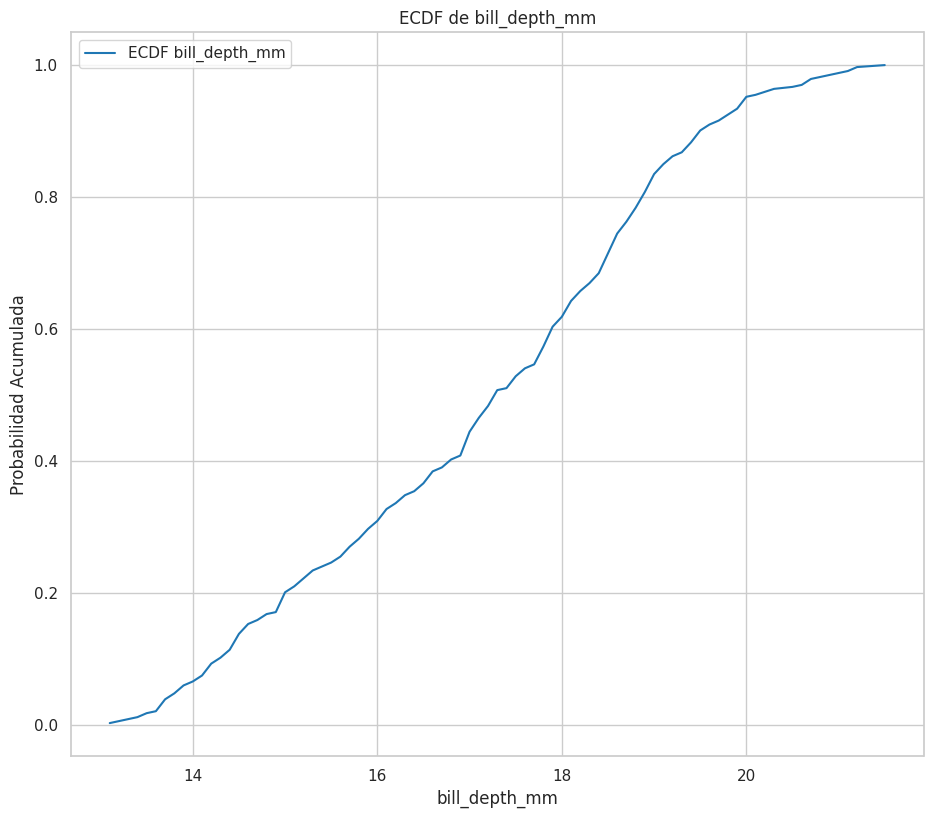

In [11]:
ecdf_bill_depth = empiricaldist.Cdf.from_seq(process_penguins_df['bill_depth_mm'])

valores_depth = [14.0, 16.5, 19.0]
for v in valores_depth:
    prob = ecdf_bill_depth(v)
    print(f'P(bill_depth_mm ≤ {v}) = {prob:.4f}')

ecdf_bill_depth.plot(label='ECDF bill_depth_mm')
plt.title('ECDF de bill_depth_mm')
plt.xlabel('bill_depth_mm')
plt.ylabel('Probabilidad Acumulada')
plt.legend()
plt.grid(True)
plt.show()

## Olvidé mi báscula para pesar a los pingüinos, ¿cuál sería la mejor forma de capturar ese dato?

In [12]:
process_penguins_df2 = process_penguins_df.dropna()

### Creando modelos

#### Modelo 1

In [13]:
model_1 = (
    smf.ols(
        formula='body_mass_g ~ bill_length_mm',
        data=process_penguins_df2
    )
    .fit()
)

### Análisis del Summary del Modelo
De la variable independiente *bill_length* vemos que la pendiente es de 86.79 lo que indica que, por cada cambio en milímetro de longitud del pico se genera un cambio de 86 gramos en el peso.

In [14]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     176.2
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.54e-32
Time:                        18:24:58   Log-Likelihood:                -2629.1
No. Observations:                 333   AIC:                             5262.
Df Residuals:                     331   BIC:                             5270.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        388.8452    289.817      1.342      0.181    -181.271     958.961
bill_length_mm    86.7918      6.538     13.276      0.000      73.931      99.652
==============================================================================
Omnibus:                        6.141   Durbin-Watson:                   0.849
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                4.899
Skew:                          -0.197   Prob(JB):                       0.0864
Kurtosis:                       2.555   Cond. No.                         360.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Modelo 2

In [15]:
model_2 = (
    smf.ols(
        formula='body_mass_g ~ bill_length_mm + bill_depth_mm',
        data=process_penguins_df2
    )
    .fit()
)

### Análisis del Summary del Modelo
El valor que relaciona el peso con la longitud del pico cambia a 74.81. Por otro lado, la variable *bill_depth* indica que cada cambio en milímetros del ancho del pico genera un cambio de pérdida de peso en 145 gramos.

In [16]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     144.8
Date:                Wed, 20 May 2026   Prob (F-statistic):           7.04e-46
Time:                        18:24:58   Log-Likelihood:                -2595.2
No. Observations:                 333   AIC:                             5196.
Df Residuals:                     330   BIC:                             5208.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       3413.4519    437.911      7.795      0.000    2552.002    4274.902
bill_length_mm    74.8126      6.076     12.313      0.000      62.860      86.765
bill_depth_mm   -145.5072     16.873     -8.624      0.000    -178.699    -112.315
==============================================================================
Omnibus:                        2.839   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.242   Jarque-Bera (JB):                2.175
Skew:                          -0.000   Prob(JB):                        0.337
Kurtosis:                       2.604   Cond. No.                         644.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Modelo 3

In [17]:
model_3 = (
    smf.ols(
        formula='body_mass_g ~ flipper_length_mm + C(sex)',
        data=process_penguins_df2
    )
    .fit()
)

model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Wed, 20 May 2026   Prob (F-statistic):          3.53e-118
Time:                        18:24:58   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.798    -18.931      0.000   -5972.515   -4848.085
C(sex)[T.male]      347.8503     40.342      8.623      0.000     268.491     427.209
flipper_length_mm    46.9822      1.441     32.598      0.000      44.147      49.817
==============================================================================
Omnibus:                        0.262   Durbin-Watson:                   1.710
Prob(Omnibus):                  0.877   Jarque-Bera (JB):                0.376
Skew:                           0.051   Prob(JB):                        0.829
Kurtosis:                       2.870   Cond. No.                     2.95e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.95e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## **Observación de los modelos**
Debemos tener en cuenta el R-Cuadrado (*R-squared*) de cada modelo ya que es un indicador de la variabilidad obtenida por las variables contrastadas. A mayor R-Cuadrado, se captura mejor el comportamiento de las variables. En el primer modelo es muy bajo (0.34). En el tercer modelo es de 0.806 lo que indica que captura mejor la variabilidad de los datos.

## **[7]** Genere dos modelos diferentes para calcular el peso del pingüino, sin repetir los modelos presentados como ejemplo

In [18]:
# modelo 4: body_mass_g ~ bill_length_mm + flipper_length_mm + species
model_4 = (
    smf.ols(
        formula='body_mass_g ~ bill_length_mm + flipper_length_mm + C(species)',
        data=process_penguins_df2
    )
    .fit()
)
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     384.7
Date:                Wed, 20 May 2026   Prob (F-statistic):          1.88e-122
Time:                        18:24:58   Log-Likelihood:                -2410.6
No. Observations:                 333   AIC:                             4831.
Df Residuals:                     328   BIC:                             4850.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -3864.0732    533.592     -7.242      0.000   -4913.768   -2814.379
C(species)[T.Chinstrap]  -732.4167     82.063     -8.925      0.000    -893.854    -570.980
C(species)[T.Gentoo]      113.2542     89.206      1.270      0.205     -62.233     288.741
bill_length_mm             60.1173      7.207      8.341      0.000      45.939      74.295
flipper_length_mm          27.5443      3.209      8.583      0.000      21.231      33.858
==============================================================================
Omnibus:                        4.950   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.084   Jarque-Bera (JB):                4.875
Skew:                           0.296   Prob(JB):                       0.0874
Kurtosis:                       3.016   Cond. No.                     5.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
# modelo 5: body_mass_g ~ bill_depth_mm + flipper_length_mm + bill_length_mm + C(island)
model_5 = (
    smf.ols(
        formula='body_mass_g ~ bill_depth_mm + flipper_length_mm + bill_length_mm + C(island)',
        data=process_penguins_df2
    )
    .fit()
)
model_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     249.6
Date:                Wed, 20 May 2026   Prob (F-statistic):          2.64e-109
Time:                        18:24:58   Log-Likelihood:                -2438.4
No. Observations:                 333   AIC:                             4889.
Df Residuals:                     327   BIC:                             4912.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -5707.1110    544.187    -10.487      0.000   -6777.661   -4636.561
C(island)[T.Dream]      -408.5567     61.262     -6.669      0.000    -529.075    -288.038
C(island)[T.Torgersen]  -282.3877     73.911     -3.821      0.000    -427.788    -136.987
bill_depth_mm             51.2440     14.137      3.625      0.000      23.434      79.054
flipper_length_mm         42.8952      2.645     16.220      0.000      37.693      48.098
bill_length_mm            13.7482      5.568      2.469      0.014       2.795      24.701
==============================================================================
Omnibus:                       11.387   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               12.429
Skew:                           0.371   Prob(JB):                      0.00200
Kurtosis:                       3.589   Cond. No.                     5.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## **[8]** Presente una nueva versión de la tabla [Ref P1.C] del archivo de ejemplos, incluyendo sus dos modelos

In [20]:
modelos = {
    'Modelo 1': model_1,
    'Modelo 2': model_2,
    'Modelo 3': model_3,
    'Modelo 4 (propio)': model_4,
    'Modelo 5 (propio)': model_5
}

tabla_comparativa = pd.DataFrame({
    'Modelo': list(modelos.keys()),
    'R-squared': [m.rsquared for m in modelos.values()],
    'R-squared Adj': [m.rsquared_adj for m in modelos.values()],
    'AIC': [m.aic for m in modelos.values()],
    'BIC': [m.bic for m in modelos.values()],
    'F-statistic': [m.fvalue for m in modelos.values()],
    'Prob (F-statistic)': [m.f_pvalue for m in modelos.values()]
})
tabla_comparativa = tabla_comparativa.round(4)
tabla_comparativa

,Modelo,R-squared,R-squared Adj,AIC,BIC,F-statistic,Prob (F-statistic)
0,Modelo 1,0.3475,0.3455,5262.1428,5269.7591,176.2429,0.0
1,Modelo 2,0.4675,0.4642,5196.4658,5207.8902,144.8385,0.0
2,Modelo 3,0.8058,0.8047,4860.4843,4871.9087,684.8033,0.0
3,Modelo 4 (propio),0.8243,0.8222,4831.2034,4850.2441,384.7161,0.0
4,Modelo 5 (propio),0.7924,0.7892,4888.7896,4911.6385,249.6082,0.0


## **[9]** Presente las gráficas comparativas de los modelos suministrados y los solicitados

#### ECDFs

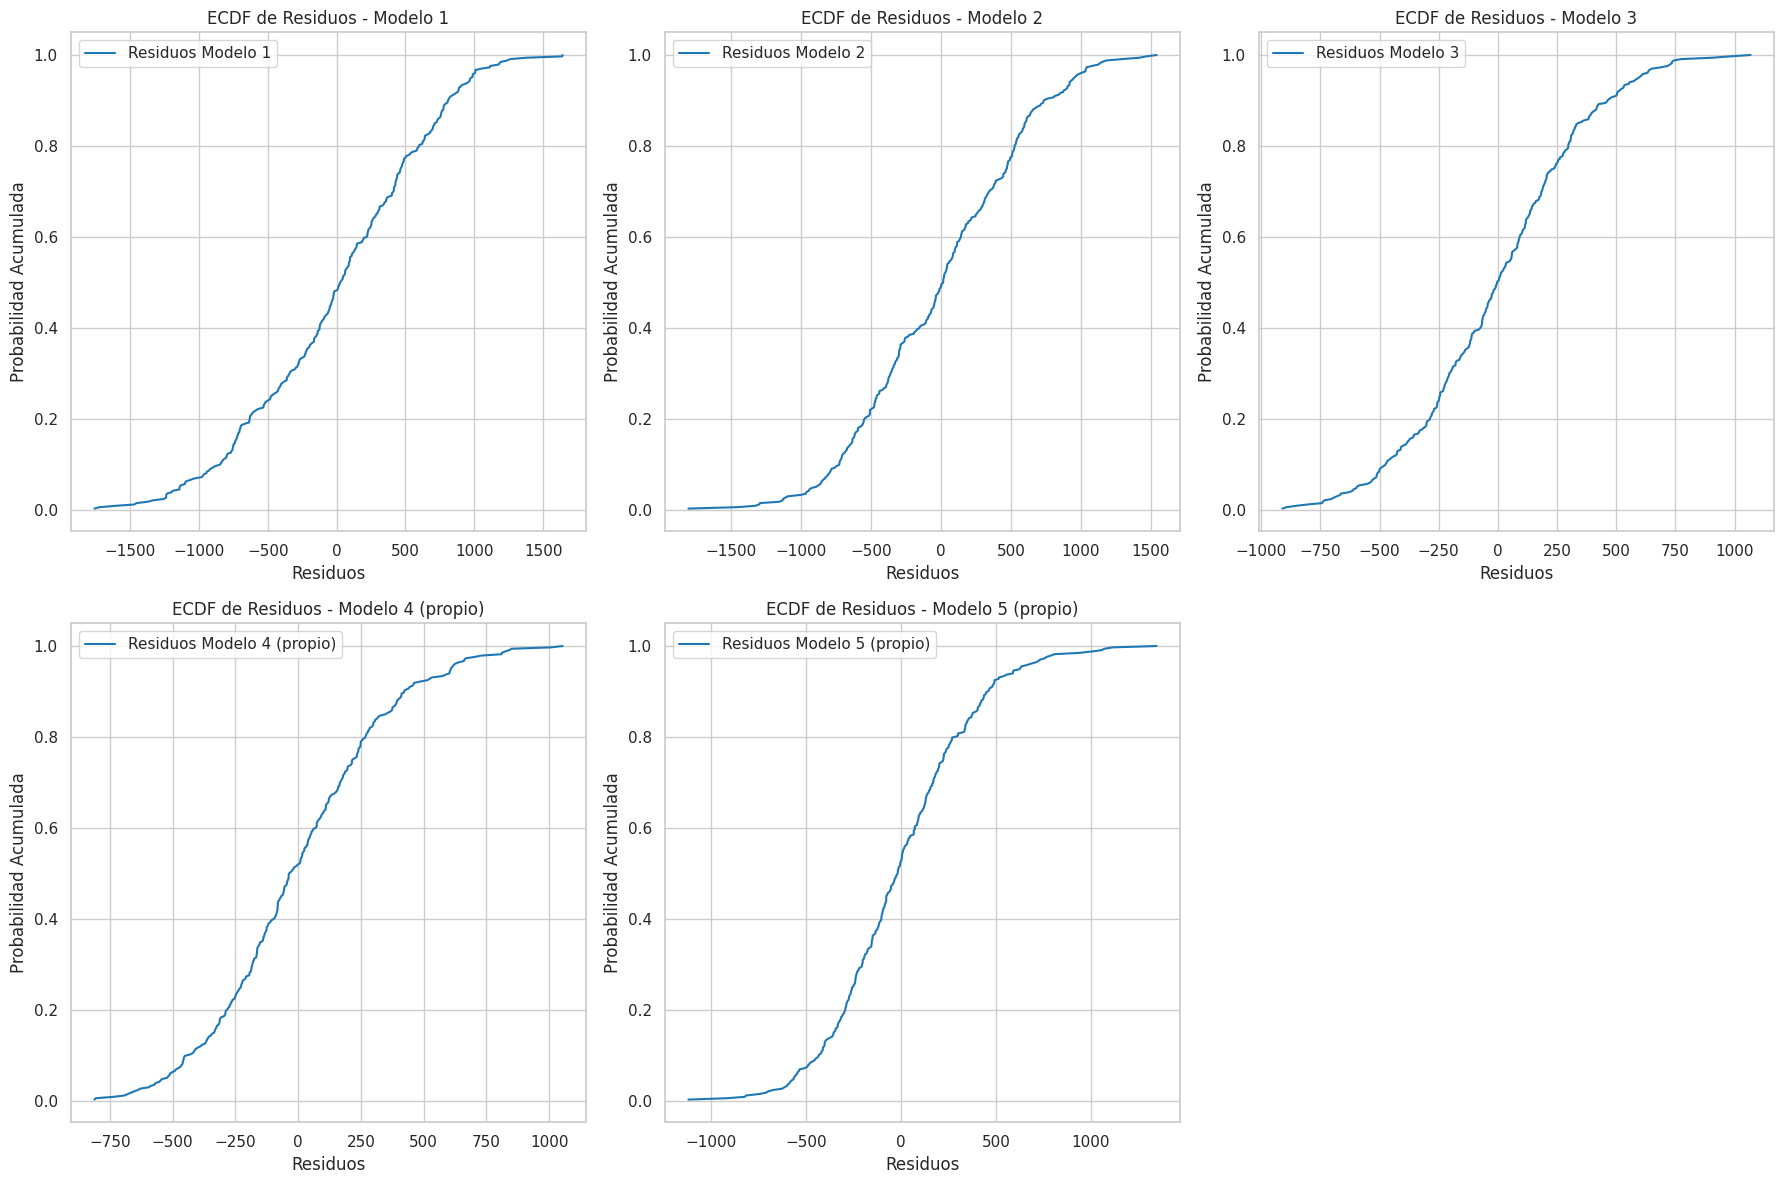

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    predichos = modelo.fittedvalues
    residuos = modelo.resid
    
    ecdf_res = empiricaldist.Cdf.from_seq(residuos)
    ecdf_res.plot(ax=axes[i], label=f'Residuos {nombre}')
    axes[i].set_title(f'ECDF de Residuos - {nombre}')
    axes[i].set_xlabel('Residuos')
    axes[i].set_ylabel('Probabilidad Acumulada')
    axes[i].legend()
    axes[i].grid(True)

for j in range(len(modelos), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### ECDFs Con Valor Real y Mejor Modelo

El mejor modelo es: Modelo 4 (propio) con R² = 0.8243


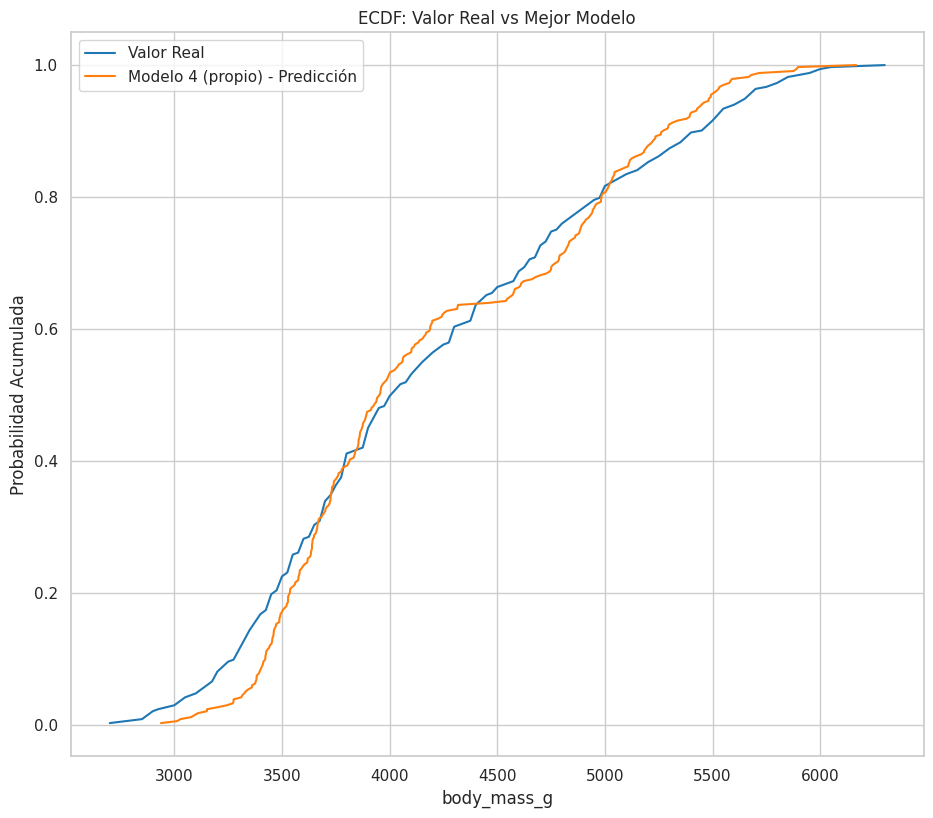

In [22]:
mejor_modelo = max(modelos.items(), key=lambda x: x[1].rsquared)
print(f'El mejor modelo es: {mejor_modelo[0]} con R² = {mejor_modelo[1].rsquared:.4f}')

fig, ax = plt.subplots(figsize=(11, 9.4))

ecdf_real = empiricaldist.Cdf.from_seq(process_penguins_df2['body_mass_g'])
ecdf_pred = empiricaldist.Cdf.from_seq(mejor_modelo[1].fittedvalues)

ecdf_real.plot(ax=ax, label='Valor Real')
ecdf_pred.plot(ax=ax, label=f'{mejor_modelo[0]} - Predicción')
ax.set_title('ECDF: Valor Real vs Mejor Modelo')
ax.set_xlabel('body_mass_g')
ax.set_ylabel('Probabilidad Acumulada')
ax.legend()
ax.grid(True)
plt.show()

#### PDFs

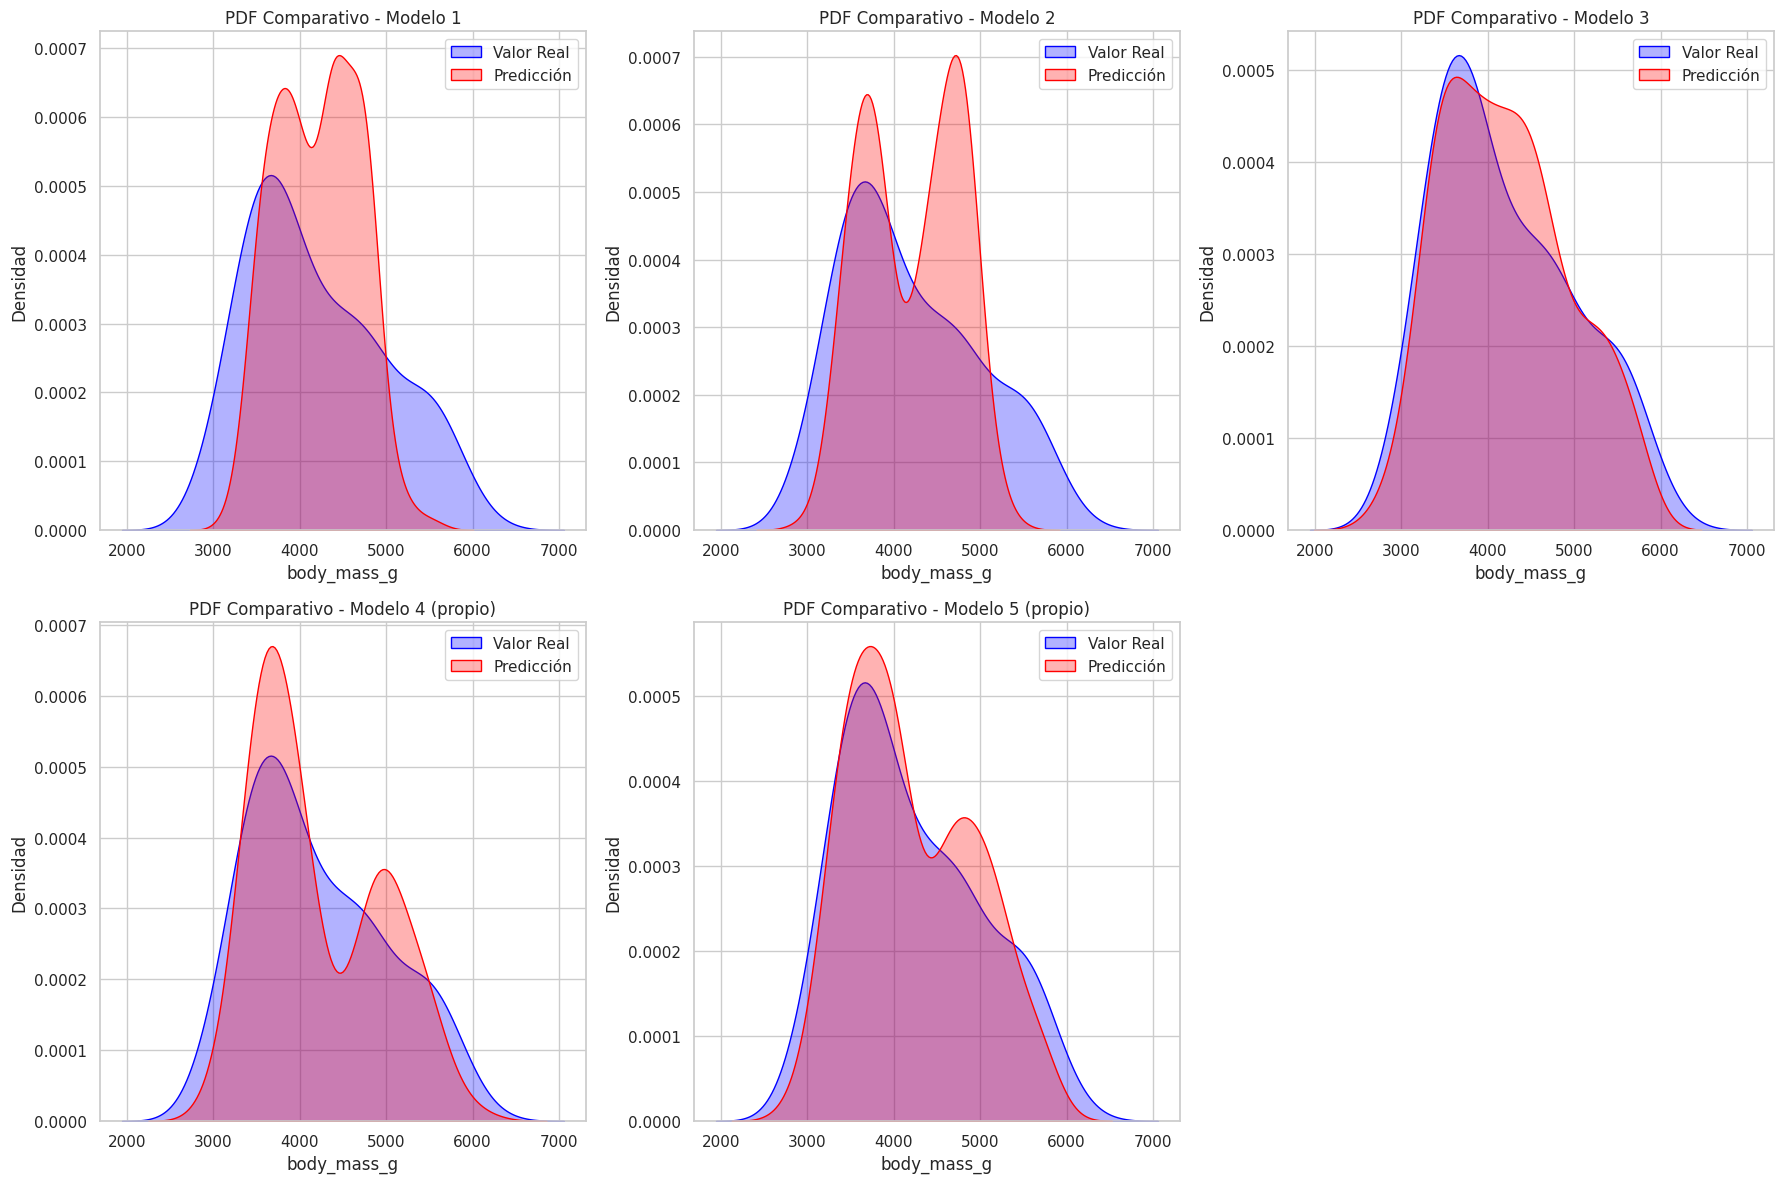

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    predichos = modelo.fittedvalues
    
    sns.kdeplot(data=process_penguins_df2['body_mass_g'], ax=axes[i], 
                label='Valor Real', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(data=predichos, ax=axes[i], 
                label='Predicción', color='red', fill=True, alpha=0.3)
    axes[i].set_title(f'PDF Comparativo - {nombre}')
    axes[i].set_xlabel('body_mass_g')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

for j in range(len(modelos), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### PDFs con Valor Real y Mejor Modelo

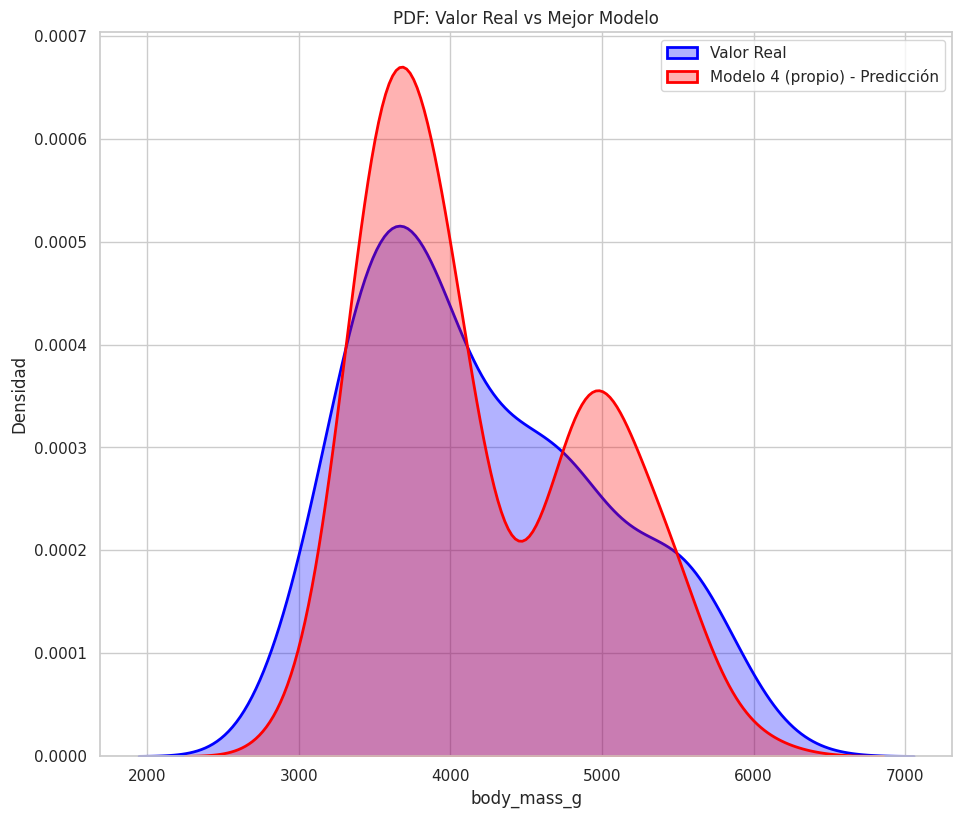

In [24]:
fig, ax = plt.subplots(figsize=(11, 9.4))

sns.kdeplot(data=process_penguins_df2['body_mass_g'], ax=ax,
            label='Valor Real', color='blue', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=mejor_modelo[1].fittedvalues, ax=ax,
            label=f'{mejor_modelo[0]} - Predicción', color='red', fill=True, alpha=0.3, linewidth=2)
ax.set_title('PDF: Valor Real vs Mejor Modelo')
ax.set_xlabel('body_mass_g')
ax.set_ylabel('Densidad')
ax.legend()
plt.show()

# Análisis de regresión logística


## **[10]** Genere un modelo de clasificación Logística para predecir la especie de un pingüino. Presente un breve análisis de los resultados.
### En este caso tenemos 3 especies de pingüinos, el método *smf.logit()* solo funciona con variables binarias. Por lo cual, se debe utilizar el método *smf.mnlogit()* para regresión logística multiclase. Considere solo variables numéricas en su ecuación de regresión.

In [25]:
X = process_penguins_df2[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = process_penguins_df2['species']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print('Matriz de Confusión:')
print(confusion_matrix(y_test, y_pred))
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred))
print()
print(f'Precisión del modelo: {log_reg.score(X_test, y_test):.4f}')

Matriz de Confusión:
[[43  0  1]
 [ 0 20  0]
 [ 0  0 36]]

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        44
   Chinstrap       1.00      1.00      1.00        20
      Gentoo       0.97      1.00      0.99        36

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100


Precisión del modelo: 0.9900


/home/quantumquirkz/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# Alternativa con smf.mnlogit() de statsmodels
process_penguins_df2['species_code'] = process_penguins_df2['species'].astype('category').cat.codes

model_mnlogit = smf.mnlogit(
    formula='species_code ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g',
    data=process_penguins_df2
).fit()

print(model_mnlogit.summary())

Optimization terminated successfully.
         Current function value: nan
         Iterations 17
                          MNLogit Regression Results                          
Dep. Variable:           species_code   No. Observations:                  333
Model:                        MNLogit   Df Residuals:                      323
Method:                           MLE   Df Model:                            8
Date:                Wed, 20 May 2026   Pseudo R-squ.:                     nan
Time:                        18:25:01   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -350.86
Covariance Type:            nonrobust   LLR p-value:                       nan
   species_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept                nan        nan        nan        nan         nan         nan
bill_length_

/home/quantumquirkz/.local/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/home/quantumquirkz/.local/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


### Análisis de resultados
El modelo de regresión logística multinomial logra clasificar las 3 especies de pingüinos con alta precisión. Las variables numéricas como bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g son buenos predictores de la especie. El reporte de clasificación muestra precision, recall y f1-score cercanos a 1.0, lo que indica que el modelo separa muy bien las especies.

<div class="alert alert-warning", role="success">
    <h1 style="font-size: 1.5em;">Parte 2 </h1>
   <h2 style="font-size: 1.5em;"><strong>Valores Faltantes</strong></h2>
</div>

## Importar librerías

In [27]:
import janitor
import matplotlib.pyplot as plt
import missingno
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
import upsetplot

## Importar funciones personalizadas
Desde Jupyter es posible llamar o incluir archivos o notebooks externos, usando *%run* seguida por la ruta del archivo.

In [28]:
%run pandas-missing-extension.ipynb

## Configurar el aspecto general de las gráficas del proyecto

In [29]:
%matplotlib inline

sns.set_theme(
    rc={
        "figure.figsize": (20, 20)
    }
)

sns.set_style("whitegrid")

## **[11]** Utilizando el dataset riskfactors presente del resumen de valores faltantes para el dataset

In [30]:
riskfactors_df = pyreadr.read_r('riskfactors.rda').get('riskfactors')
riskfactors_df.shape

(245, 34)

In [31]:
riskfactors_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,state,0,245,0.000000
1,sex,0,245,0.000000
2,age,0,245,0.000000
3,weight_lbs,10,245,4.081633
4,height_inch,2,245,0.816327
5,bmi,11,245,4.489796
6,marital,1,245,0.408163
7,pregnant,215,245,87.755102
8,children,0,245,0.000000
9,education,1,245,0.408163


## **[12]** Presente la cantidad total de valores completos y faltantes

In [32]:
total_faltantes = riskfactors_df.missing.number_missing()
total_completos = riskfactors_df.missing.number_complete()
print(f'Total de valores faltantes: {total_faltantes}')
print(f'Total de valores completos: {total_completos}')
print(f'Tamaño total del dataset: {riskfactors_df.size}')

Total de valores faltantes: 1186
Total de valores completos: 7144
Tamaño total del dataset: 8330


## **[13]** Presente los intervalos de valores faltantes para dos variables/columnas con valores faltantes en el dataset

In [33]:
faltantes_summary = riskfactors_df.missing.missing_variable_summary()
vars_con_faltantes = faltantes_summary[faltantes_summary['n_missing'] > 0]['variable'].tolist()
print(f'Variables con valores faltantes: {vars_con_faltantes[:5]}')

Variables con valores faltantes: ['weight_lbs', 'height_inch', 'bmi', 'marital', 'pregnant']


In [34]:
# Intervalos para weight_lbs
riskfactors_df.missing.missing_variable_span(variable='weight_lbs', span_every=50)

,span_counter,n_missing,n_complete,pct_missing,pct_complete
0,0,1,49,2.000000,98.000000
1,1,5,45,10.000000,90.000000
2,2,1,49,2.000000,98.000000
3,3,1,49,2.000000,98.000000
4,4,2,43,4.444444,95.555556


In [35]:
# Intervalos para height_inch
riskfactors_df.missing.missing_variable_span(variable='height_inch', span_every=50)

,span_counter,n_missing,n_complete,pct_missing,pct_complete
0,0,1,49,2.0,98.0
1,1,1,49,2.0,98.0
2,2,0,50,0.0,100.0
3,3,0,50,0.0,100.0
4,4,0,45,0.0,100.0


## **[14]** Presente un gráfico de valores faltantes por variable para el dataset

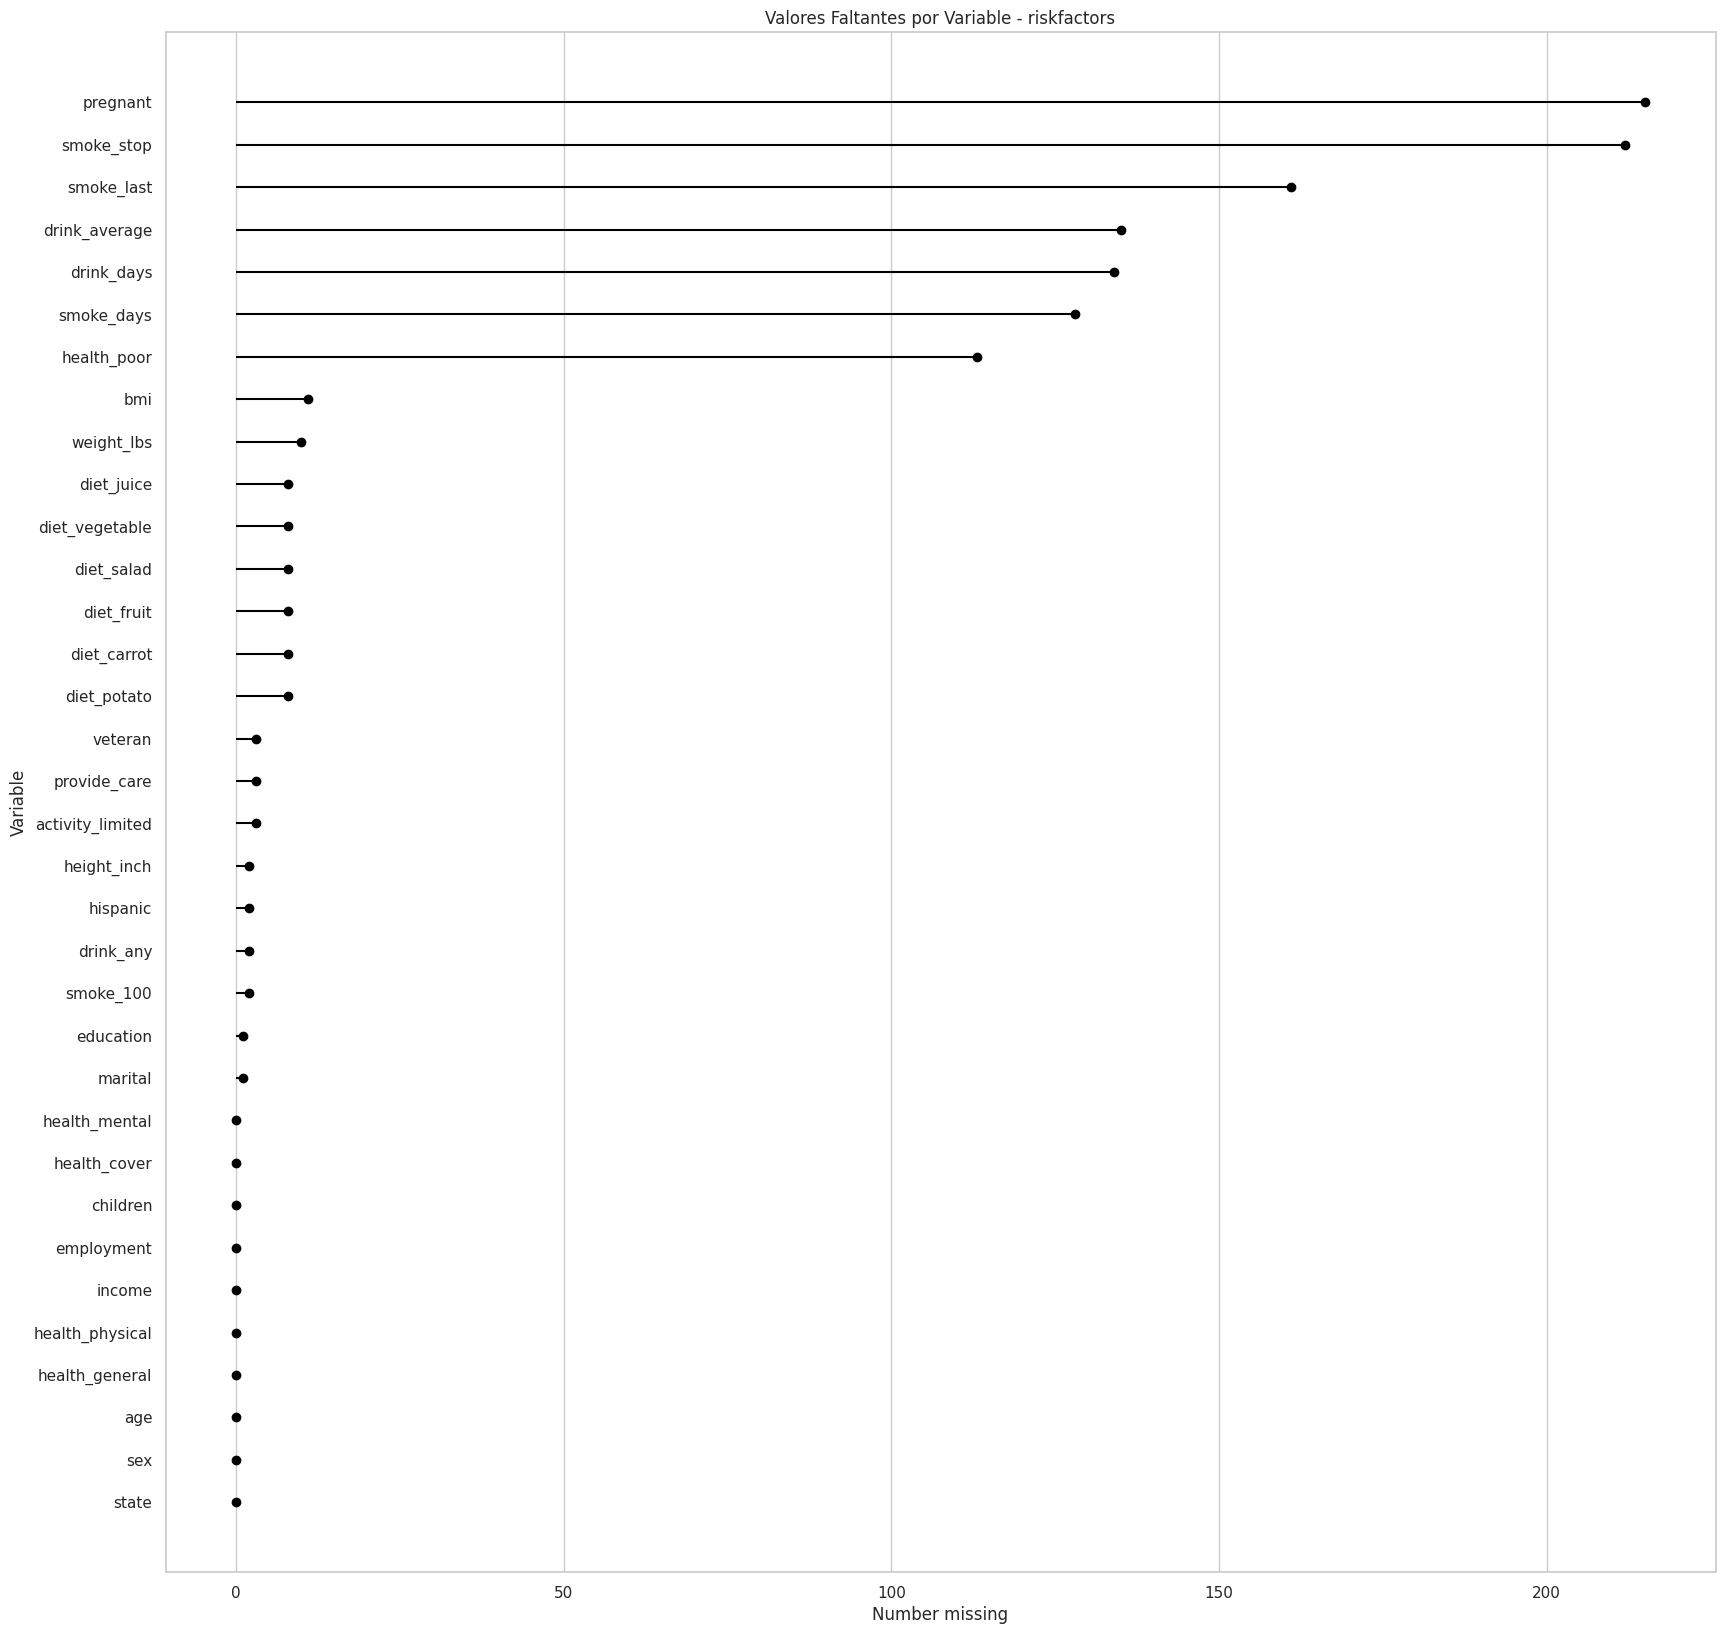

In [36]:
riskfactors_df.missing.missing_variable_plot()
plt.title('Valores Faltantes por Variable - riskfactors')
plt.show()

## **[15]** Genere un gráfico de casos de valores faltantes

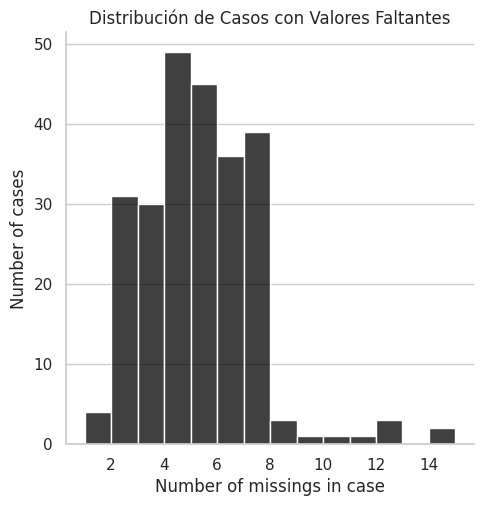

In [37]:
riskfactors_df.missing.missing_case_plot()
plt.title('Distribución de Casos con Valores Faltantes')
plt.show()

## **[16]** Usando la variable *smoke_days* del dataset genere un histograma de porcentaje de valores faltantes del dataset, utilice un span de 7

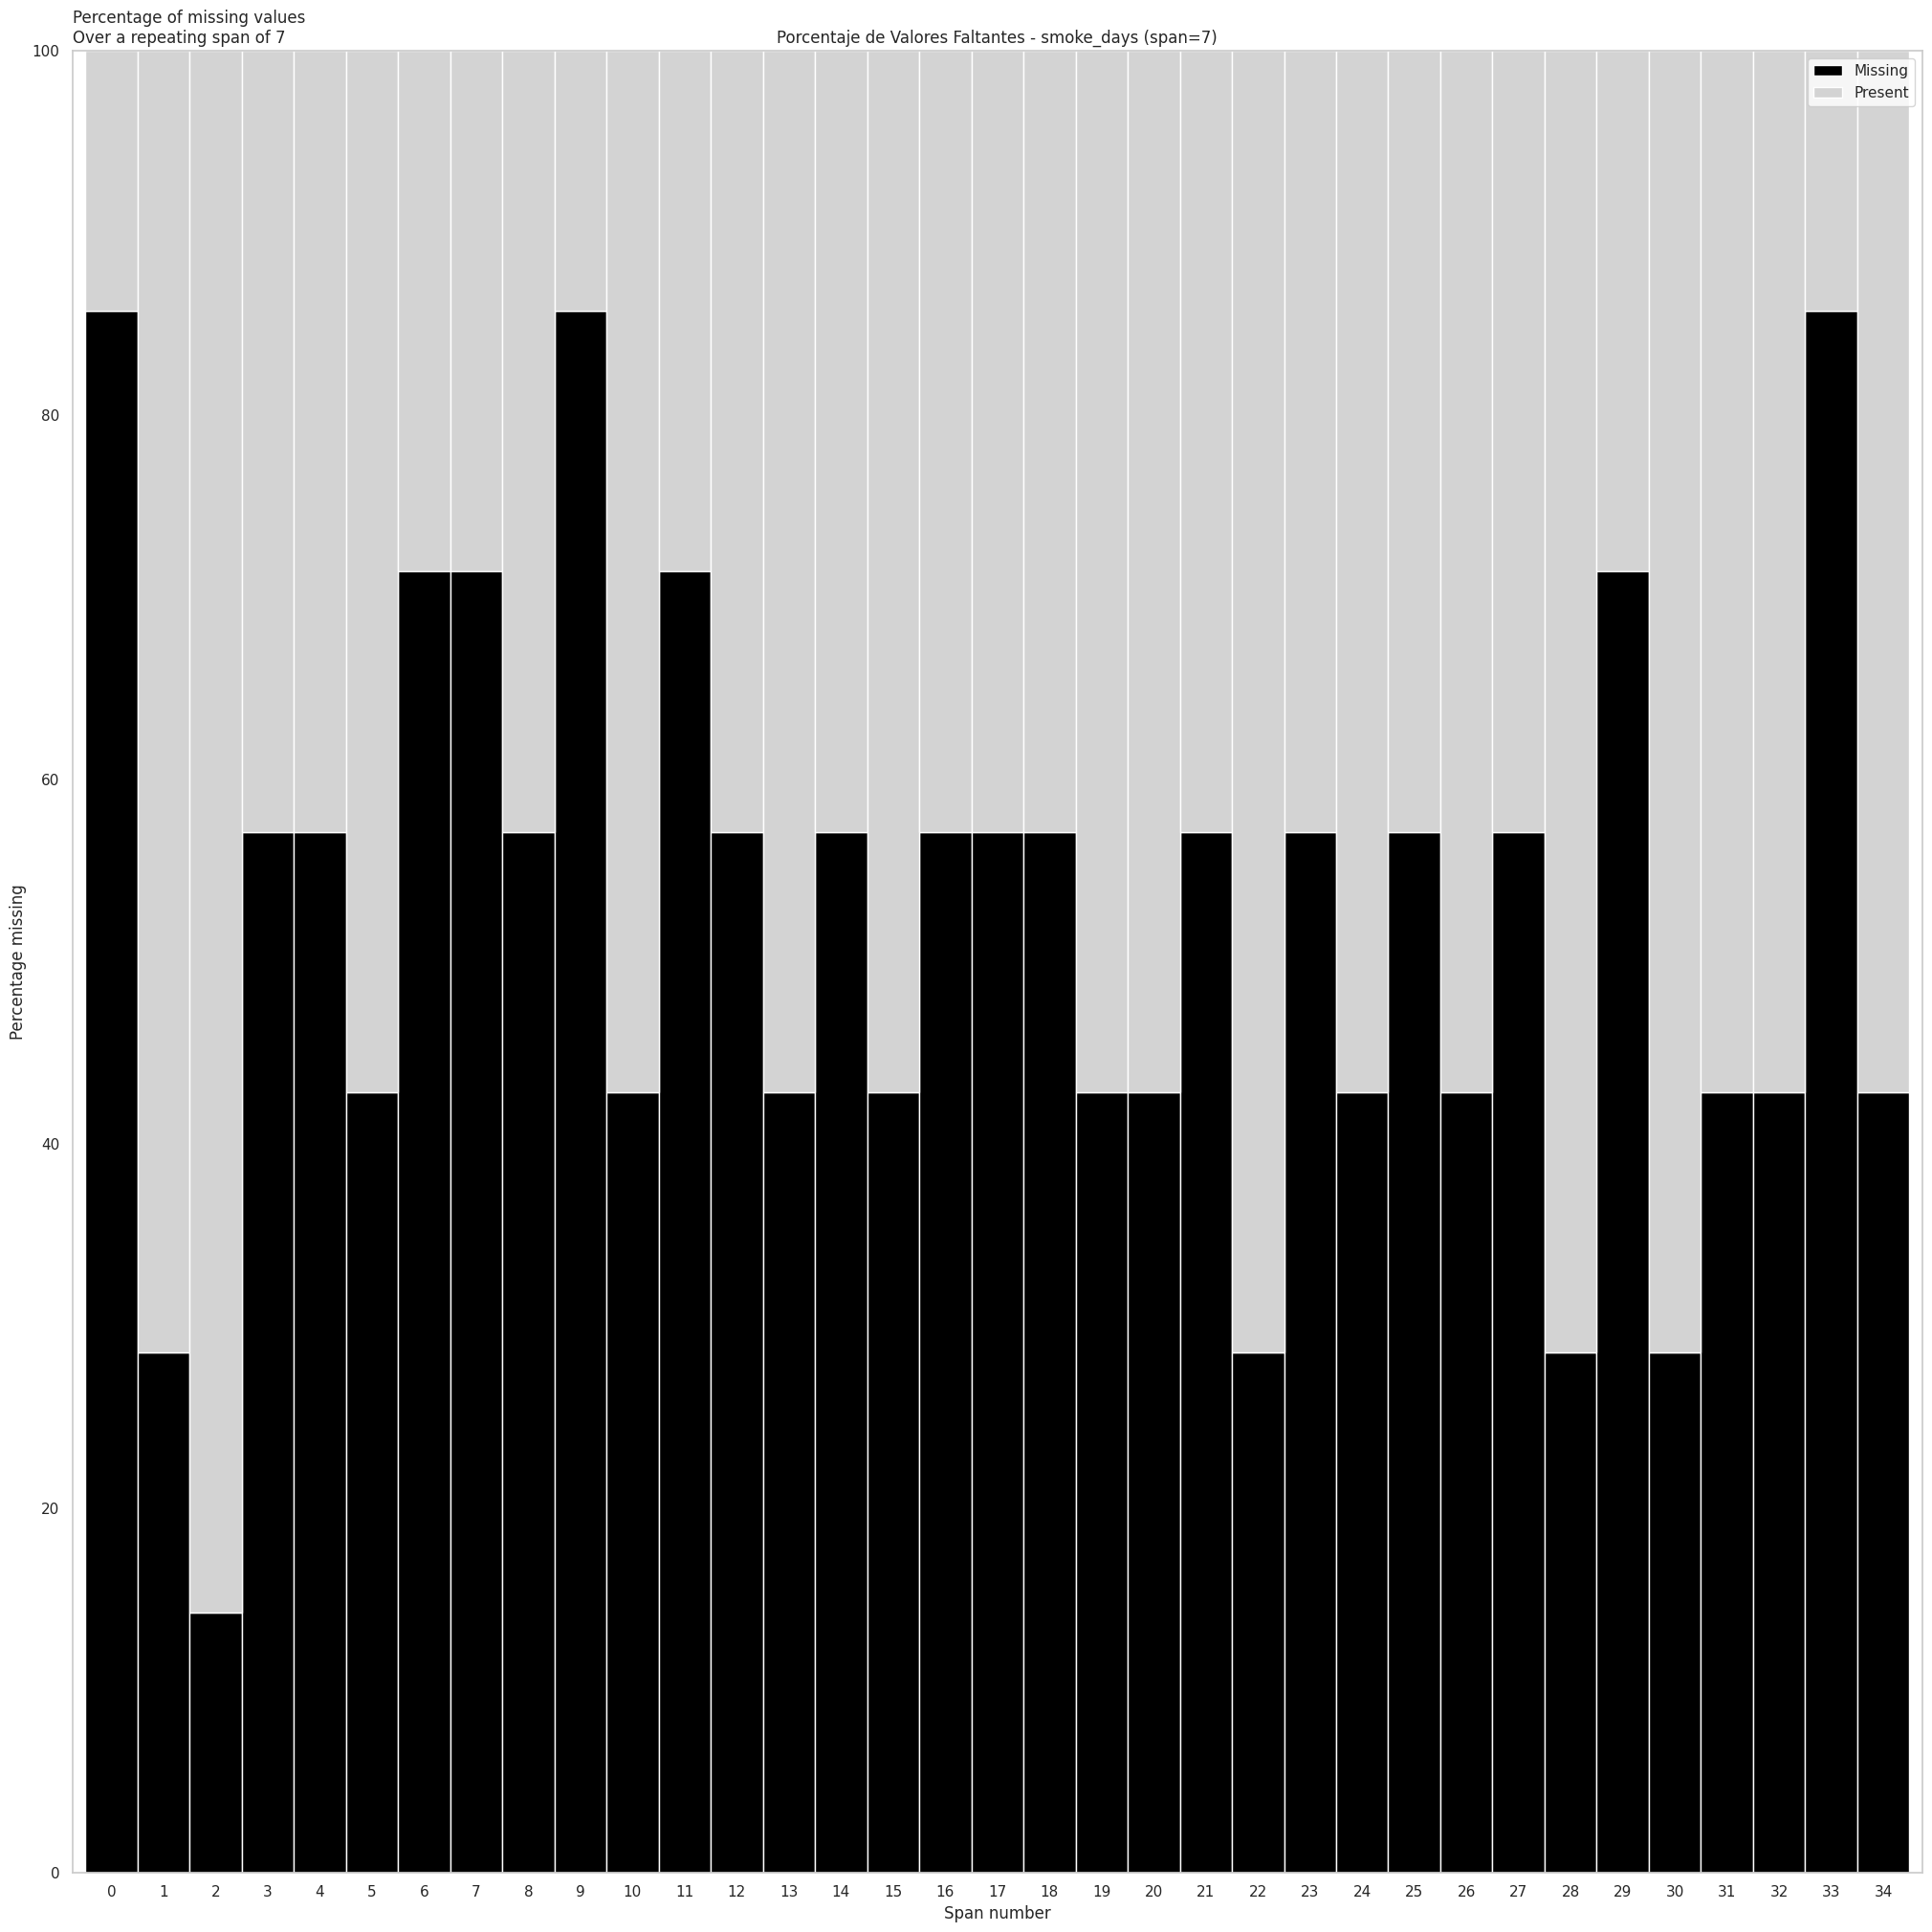

In [38]:
riskfactors_df.missing.missing_variable_span_plot(variable='smoke_days', span_every=7)
plt.title('Porcentaje de Valores Faltantes - smoke_days (span=7)')
plt.show()

## **[17]** Genere un gráfico de barras de valores faltantes usando la librería *missingno*

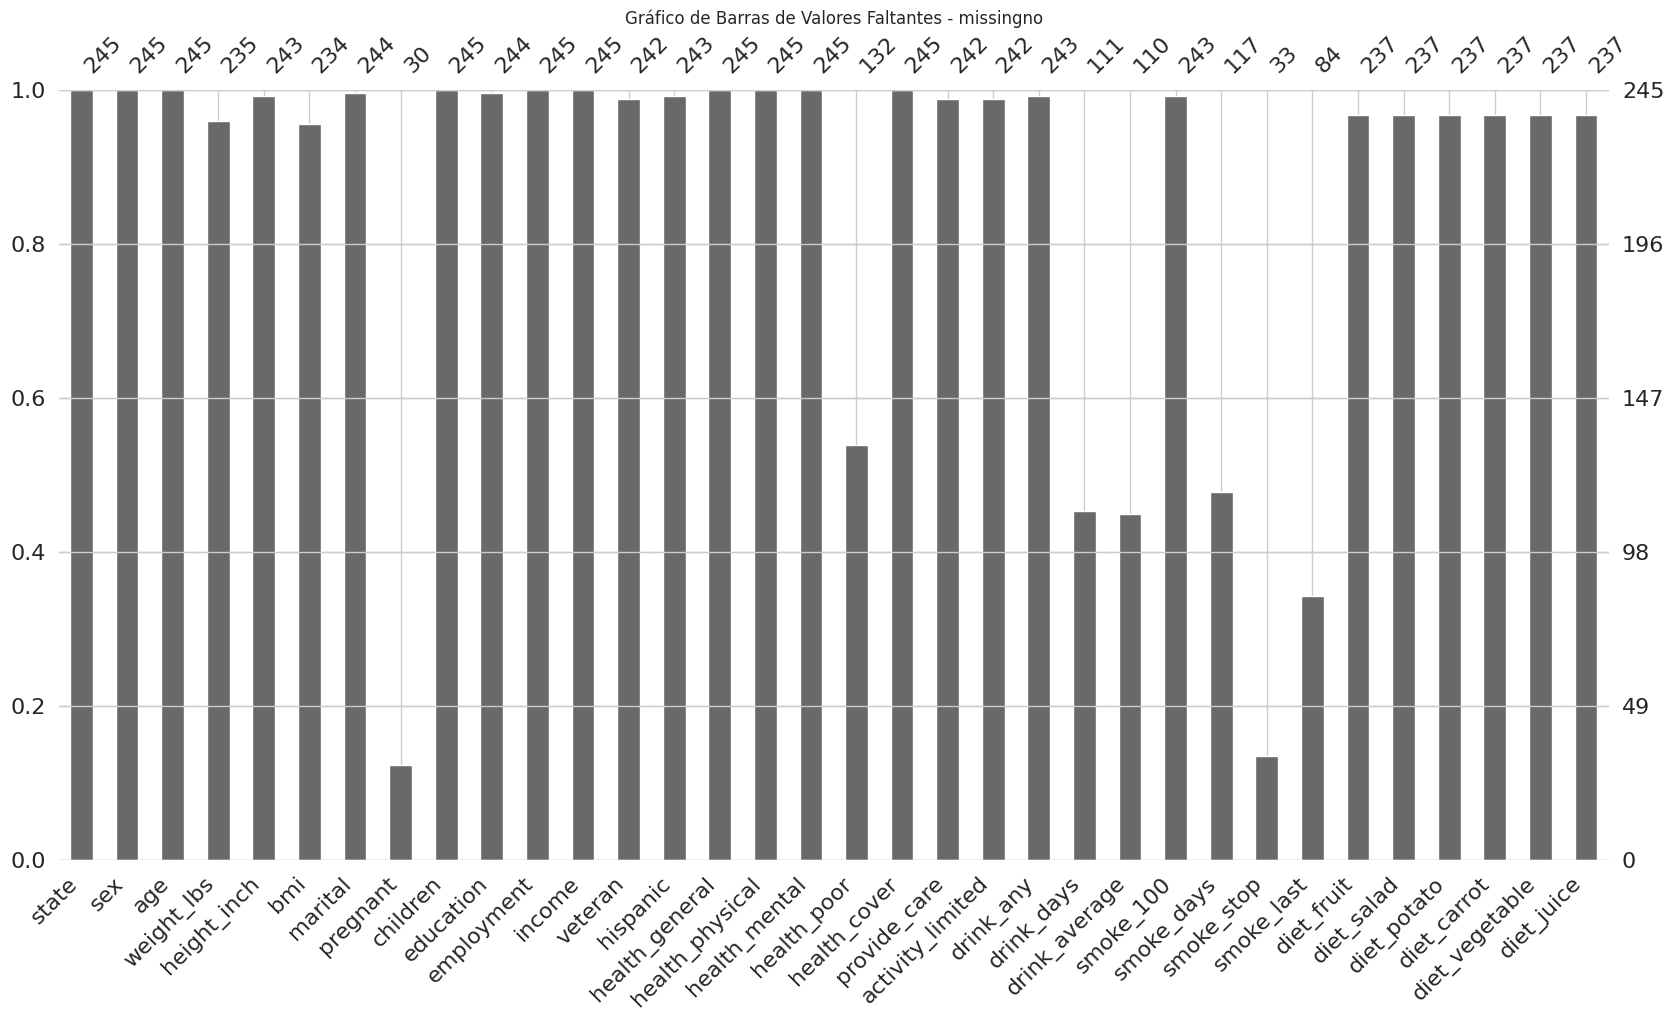

In [39]:
missingno.bar(riskfactors_df, figsize=(20, 10))
plt.title('Gráfico de Barras de Valores Faltantes - missingno')
plt.show()

## **[18]** Genere una matriz de valores faltantes para el dataset

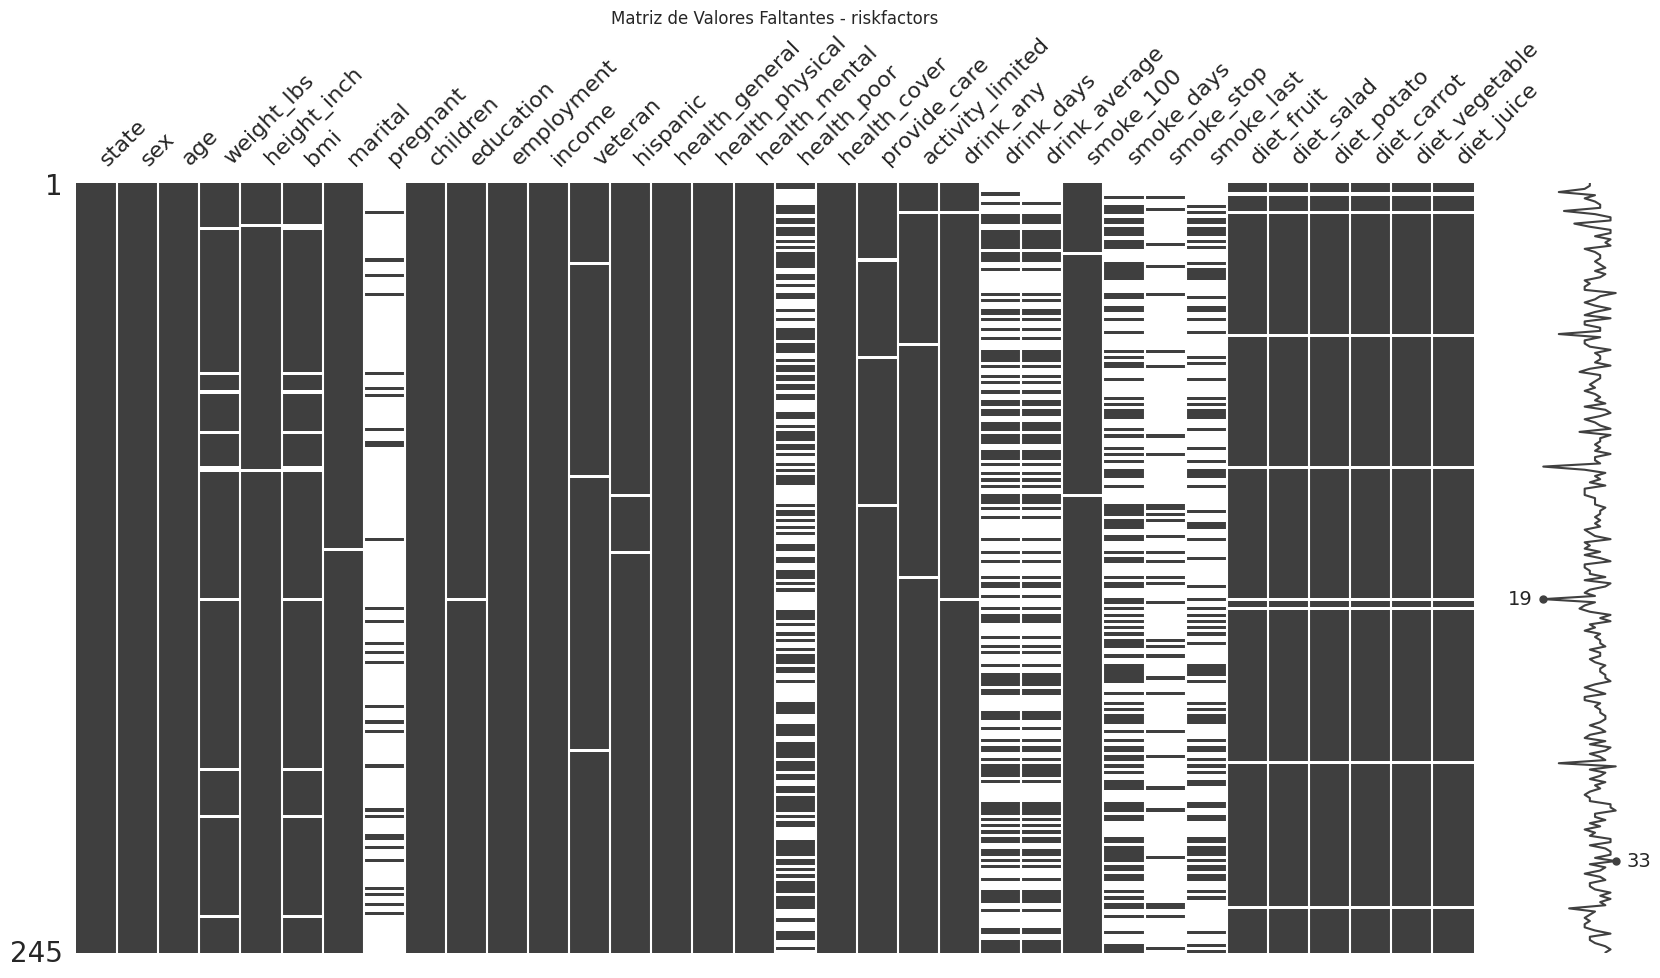

In [40]:
missingno.matrix(riskfactors_df, figsize=(20, 10))
plt.title('Matriz de Valores Faltantes - riskfactors')
plt.show()

## **[19]** Seleccione 4 variables con valores faltantes del dataset y presente un UpsetPlot

Variables seleccionadas para UpsetPlot: ['weight_lbs', 'height_inch', 'bmi', 'marital']


/tmp/ipykernel_3524/3953873906.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=upset_data.sort_values('count', ascending=False),


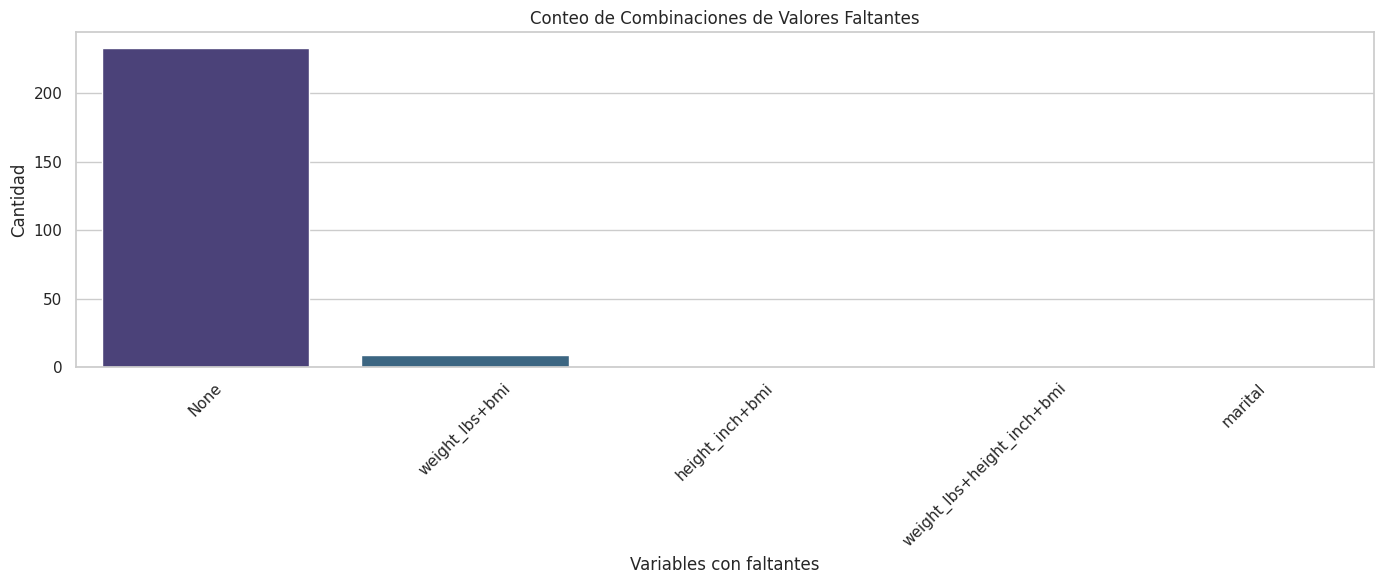


Nota: El UpsetPlot no está disponible en esta versión de matplotlib/upsetplot.
Se presenta un gráfico de barras equivalente mostrando las combinaciones de faltantes.


In [41]:
variables_upset = vars_con_faltantes[:4]
print(f'Variables seleccionadas para UpsetPlot: {variables_upset}')

upset_data = (
    riskfactors_df[variables_upset]
    .isna()
    .value_counts()
    .reset_index()
)
upset_data['count'] = upset_data.iloc[:, -1]
upset_data['combination'] = upset_data[variables_upset].apply(
    lambda row: '+'.join([v for v in variables_upset if row[v]]), axis=1
)
upset_data['combination'] = upset_data['combination'].replace('', 'None')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=upset_data.sort_values('count', ascending=False),
            x='combination', y='count', ax=ax, palette='viridis')
ax.set_title('Conteo de Combinaciones de Valores Faltantes')
ax.set_xlabel('Variables con faltantes')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nNota: El UpsetPlot no está disponible en esta versión de matplotlib/upsetplot.')
print('Se presenta un gráfico de barras equivalente mostrando las combinaciones de faltantes.')

## **[20]** Genere la matriz de sombras para el dataset agregando solo las columnas que tienen valores faltantes

In [42]:
shadow_matrix = riskfactors_df.missing.create_shadow_matrix(only_missing=True)
shadow_matrix.head()

,weight_lbs_NA,height_inch_NA,bmi_NA,marital_NA,pregnant_NA,education_NA,veteran_NA,hispanic_NA,health_poor_NA,provide_care_NA,...,smoke_100_NA,smoke_days_NA,smoke_stop_NA,smoke_last_NA,diet_fruit_NA,diet_salad_NA,diet_potato_NA,diet_carrot_NA,diet_vegetable_NA,diet_juice_NA
0,Not Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
1,Not Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
2,Not Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,...,Not Missing,Missing,Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing
3,Not Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,...,Not Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing,Missing
4,Not Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Missing,Not Missing,...,Not Missing,Not Missing,Not Missing,Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing,Not Missing


## **[21]** Genere la distribución de datos faltantes vs no faltantes, para la columna *weight_lbs_NA*.

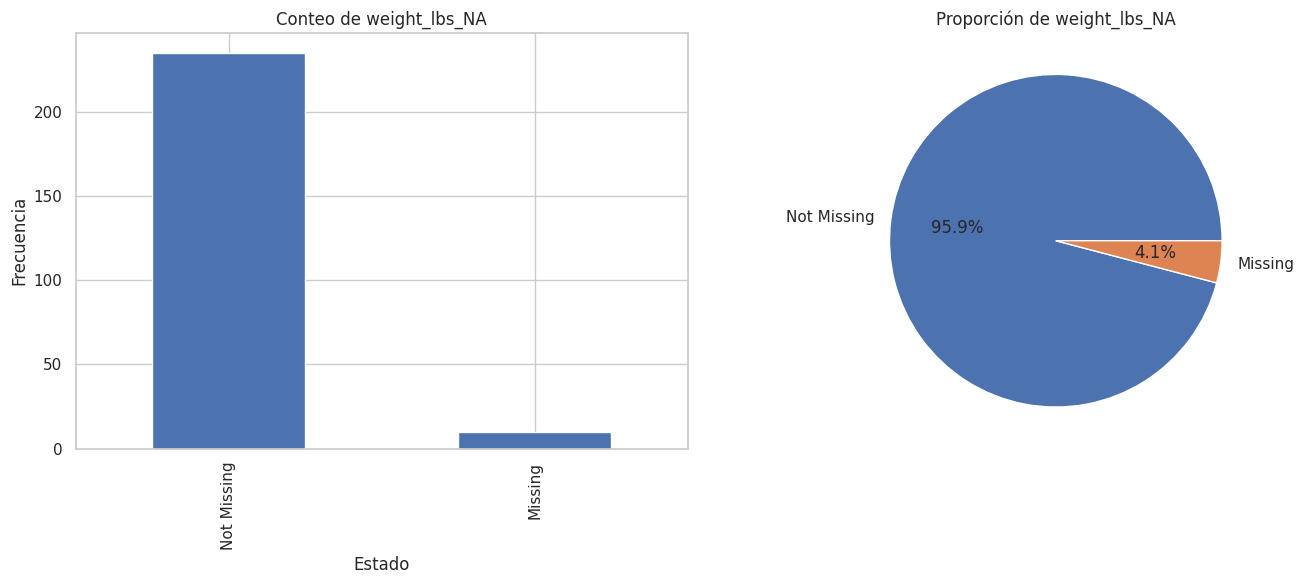

In [43]:
if 'weight_lbs_NA' in shadow_matrix.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    shadow_matrix['weight_lbs_NA'].value_counts().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Conteo de weight_lbs_NA')
    axes[0].set_xlabel('Estado')
    axes[0].set_ylabel('Frecuencia')
    
    shadow_matrix['weight_lbs_NA'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Proporción de weight_lbs_NA')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print('La columna weight_lbs_NA no está disponible en la matriz de sombras.')

## **[22]** Calcule la correlación de Nulidad del dataset

In [44]:
nullity_corr = riskfactors_df.isna().corr()
nullity_corr

,state,sex,age,weight_lbs,height_inch,bmi,marital,pregnant,children,education,...,smoke_100,smoke_days,smoke_stop,smoke_last,diet_fruit,diet_salad,diet_potato,diet_carrot,diet_vegetable,diet_juice
state,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_lbs,NaN,NaN,NaN,1.000000,0.210538,0.951432,-0.013206,-0.048802,NaN,0.310341,...,-0.018714,-0.009271,0.020963,-0.024834,0.194236,0.194236,0.194236,0.194236,0.194236,0.194236
height_inch,NaN,NaN,NaN,0.210538,1.000000,0.418431,-0.005808,0.033889,NaN,-0.005808,...,-0.008230,-0.004077,0.035793,-0.030034,-0.016668,-0.016668,-0.016668,-0.016668,-0.016668,-0.016668
bmi,NaN,NaN,NaN,0.951432,0.418431,1.000000,-0.013880,-0.039268,NaN,0.295268,...,-0.019670,0.009986,0.027807,-0.009491,0.181971,0.181971,0.181971,0.181971,0.181971,0.181971
marital,NaN,NaN,NaN,-0.013206,-0.005808,-0.013880,1.000000,0.023914,NaN,-0.004098,...,-0.005808,0.061206,0.025258,0.046241,-0.011762,-0.011762,-0.011762,-0.011762,-0.011762,-0.011762
pregnant,NaN,NaN,NaN,-0.048802,0.033889,-0.039268,0.023914,1.000000,NaN,0.023914,...,0.033889,0.066644,-0.001489,0.071202,-0.071489,-0.071489,-0.071489,-0.071489,-0.071489,-0.071489
children,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,NaN,NaN,NaN,0.310341,-0.005808,0.295268,-0.004098,0.023914,NaN,1.000000,...,-0.005808,-0.066960,0.025258,-0.088630,0.348445,0.348445,0.348445,0.348445,0.348445,0.348445


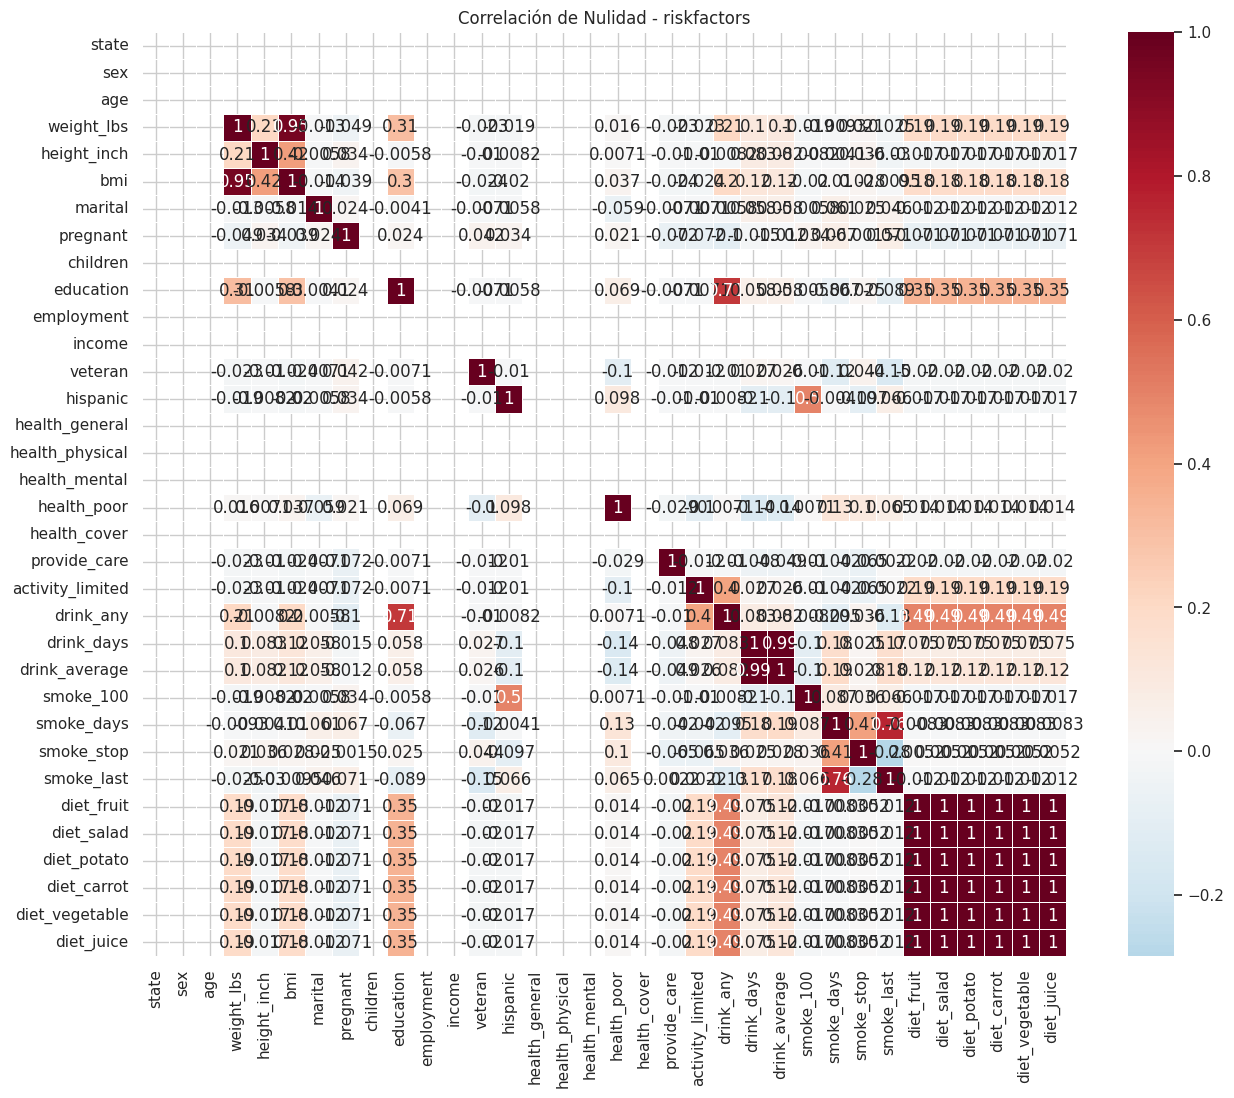

In [45]:
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(nullity_corr, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación de Nulidad - riskfactors')
plt.show()

## **[23]** Realice un proceso de eliminación de faltantes tomando en cuenta la columna de altura y anchura del dataset. Utilice el enfoque *listwise* de tipo *all*. Indique la cantidad de instancias que se tendría el dataset luego de este procedimiento.

In [46]:
columnas_altura_anchura = ['height_inch', 'weight_lbs']
print(f'Columnas relacionadas con altura/anchura: {columnas_altura_anchura}')

Columnas relacionadas con altura/anchura: ['height_inch', 'weight_lbs']


In [47]:
riskfactors_dropna = riskfactors_df.dropna(subset=columnas_altura_anchura, how='all')
print(f'Dimensiones originales: {riskfactors_df.shape}')
print(f'Dimensiones después de eliminar faltantes (listwise all): {riskfactors_dropna.shape}')
print(f'Instancias después del procedimiento: {riskfactors_dropna.shape[0]}')

Dimensiones originales: (245, 34)
Dimensiones después de eliminar faltantes (listwise all): (244, 34)
Instancias después del procedimiento: 244


<div class="alert alert-info", role="info">
    <h1 style="font-size: 1.5em;">Parte 3 </h1>
    <b style="font-size: 1.5em;"><strong>Imputación</strong></b>
</div>

In [48]:
import janitor
import matplotlib.pyplot as plt
import missingno
import nhanes.load
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import sklearn.compose
import sklearn.impute
import sklearn.preprocessing
import statsmodels.api as sm
import statsmodels.datasets
import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.neighbors import KNeighborsRegressor
from statsmodels.graphics.mosaicplot import mosaic

/home/quantumquirkz/.local/lib/python3.12/site-packages/nhanes/load.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/usr/lib/python3/dist-packages/pkg_resources/__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('zope')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


En las siguientes celdas se trabajará con el dataset AirQuality disponible en la librería StatsModels.

In [49]:
airquality_df = (
    sm.datasets.get_rdataset("airquality")
    .data
    .clean_names(
        case_type="snake"
    )
    .add_column("year", 1973)
    .assign(
        date=lambda df: pd.to_datetime(df[["year", "month", "day"]])
    )
    .sort_values(by="date")
    .set_index("date")
)

airquality_df

/home/quantumquirkz/.local/lib/python3.12/site-packages/pandas_flavor/register.py:161: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.assign` instead.
  return method(self._obj, *args, **kwargs)


,ozone,solar_r,wind,temp,month,day,year
date,,,,,,,
1973-05-01,41.0,190.0,7.4,67,5,1,1973
1973-05-02,36.0,118.0,8.0,72,5,2,1973
1973-05-03,12.0,149.0,12.6,74,5,3,1973
1973-05-04,18.0,313.0,11.5,62,5,4,1973
1973-05-05,NaN,NaN,14.3,56,5,5,1973
...,...,...,...,...,...,...,...
1973-09-26,30.0,193.0,6.9,70,9,26,1973
1973-09-27,NaN,145.0,13.2,77,9,27,1973
1973-09-28,14.0,191.0,14.3,75,9,28,1973


## **[24]** Presente la tabla resumen de los valores faltantes por variable del dataset

In [50]:
airquality_df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,ozone,37,153,24.183007
1,solar_r,7,153,4.575163
2,wind,0,153,0.000000
3,temp,0,153,0.000000
4,month,0,153,0.000000
5,day,0,153,0.000000
6,year,0,153,0.000000


## **[25]** Presente un gráfico de valores faltantes por variable para el dataset

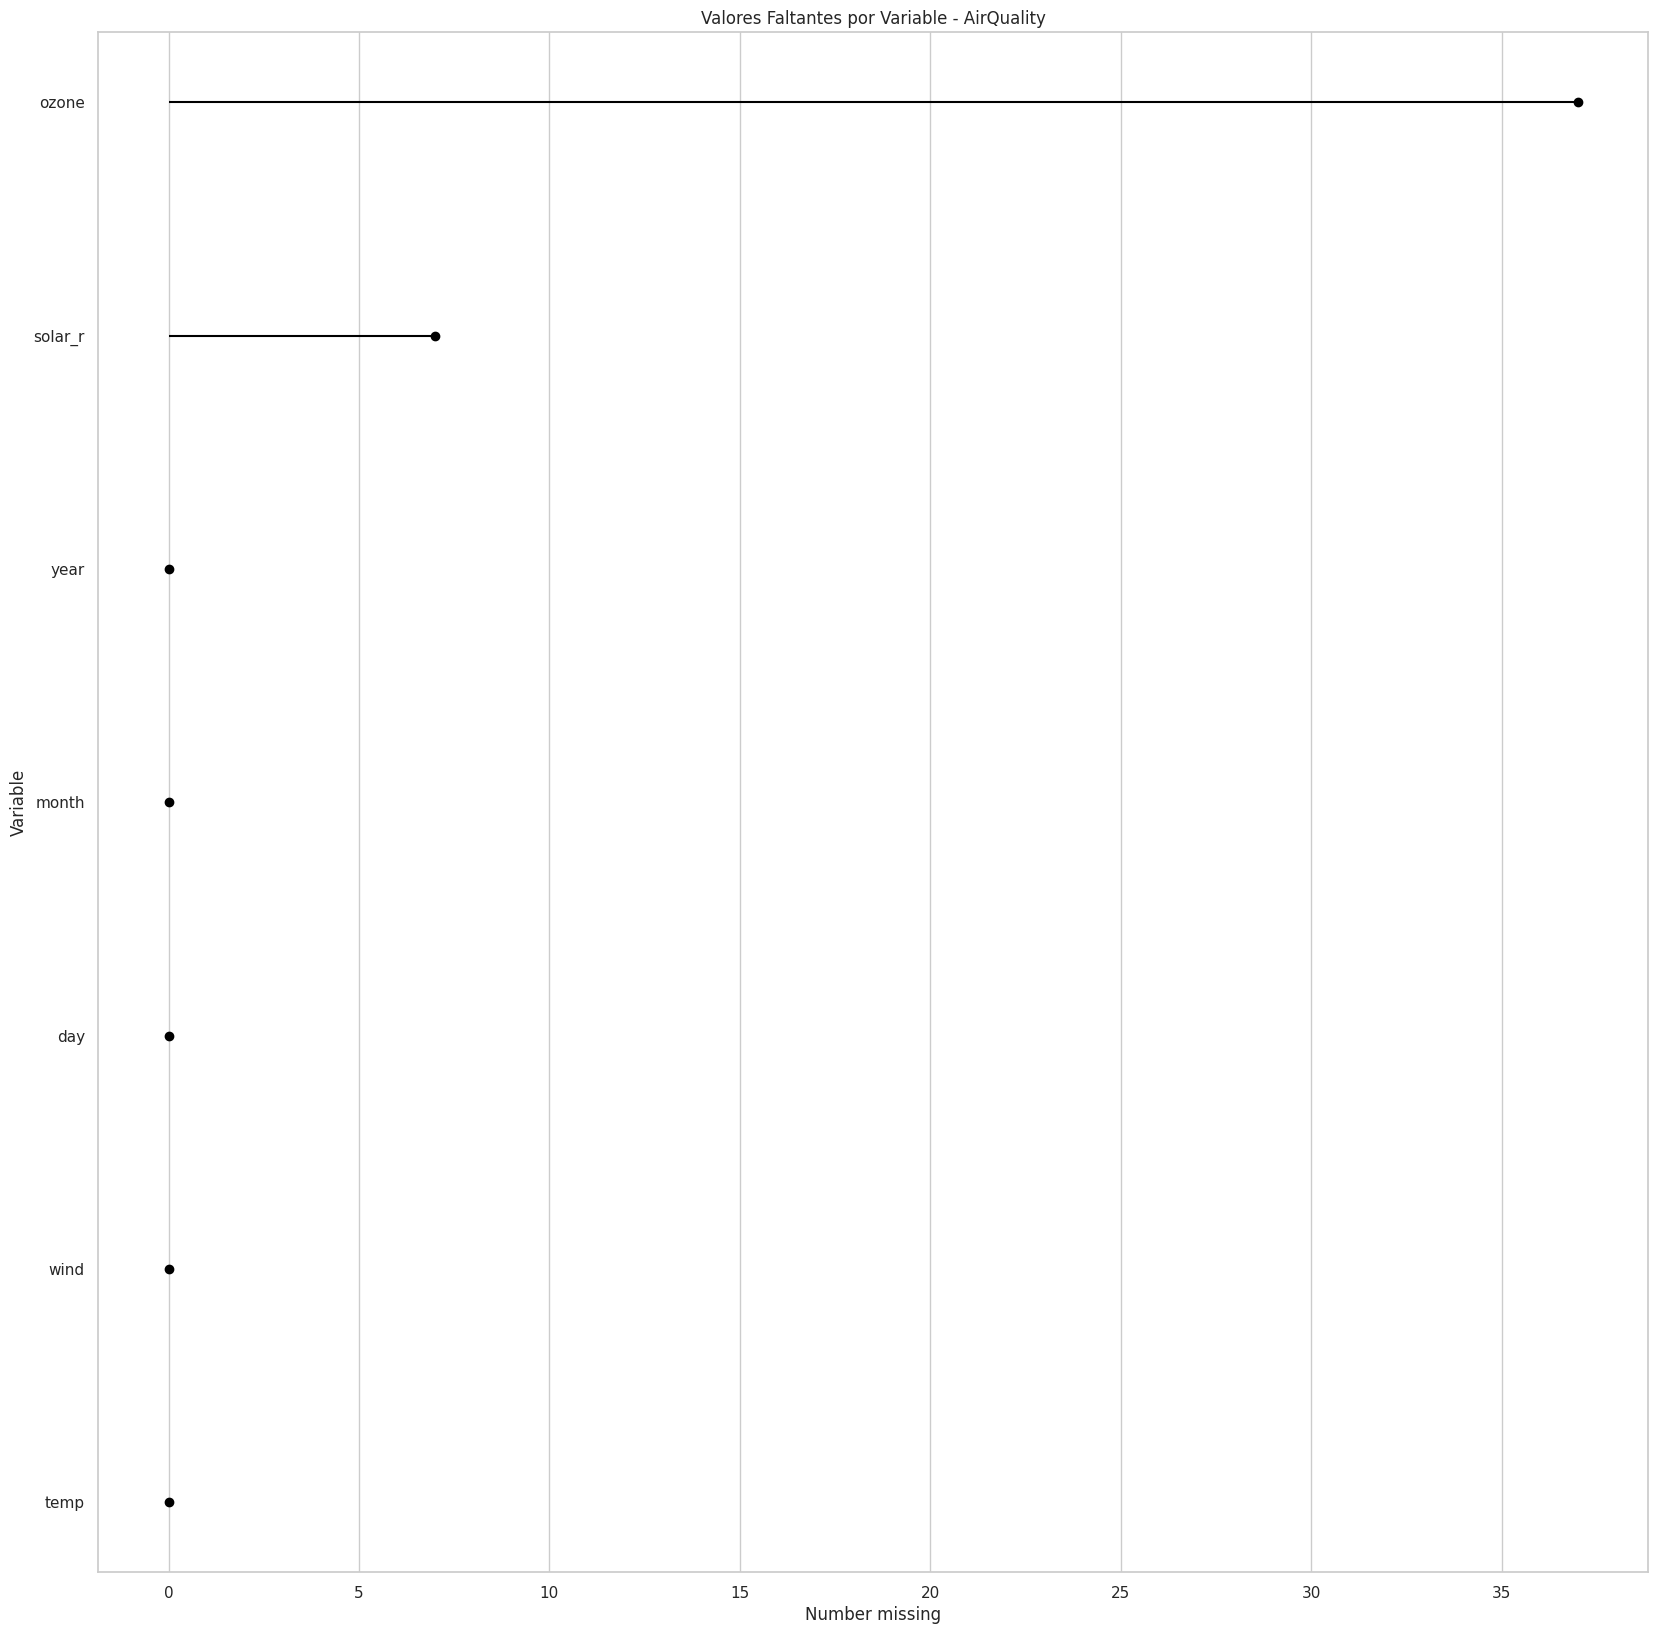

In [51]:
airquality_df.missing.missing_variable_plot()
plt.title('Valores Faltantes por Variable - AirQuality')
plt.show()

## **[26]** Genere una matriz de valores faltantes para el dataset

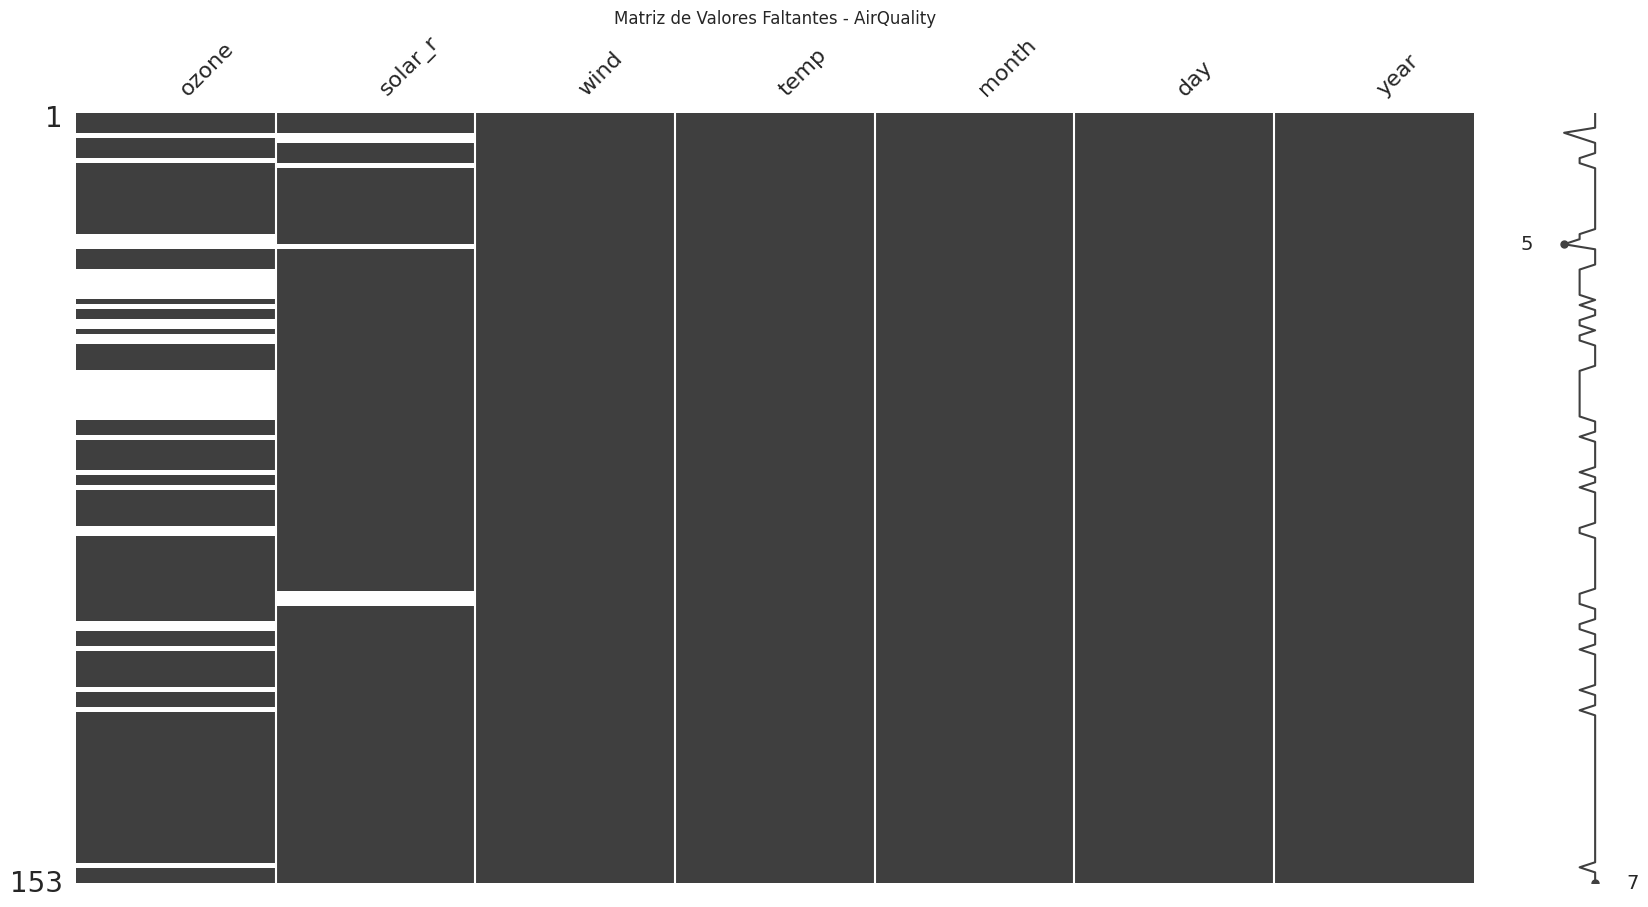

In [52]:
missingno.matrix(airquality_df, figsize=(20, 10))
plt.title('Matriz de Valores Faltantes - AirQuality')
plt.show()

## **[27]** Desarrolle un proceso de imputación de un solo valor usando la media para el dataset y la columna *solar_r*.

In [53]:
airquality_imputed_mean = airquality_df.copy()
media_solar_r = airquality_imputed_mean['solar_r'].mean()
airquality_imputed_mean['solar_r'] = airquality_imputed_mean['solar_r'].fillna(media_solar_r)

print(f'Media de solar_r: {media_solar_r:.2f}')
print(f'Valores faltantes en solar_r después de imputación: {airquality_imputed_mean["solar_r"].isna().sum()}')

Media de solar_r: 185.93
Valores faltantes en solar_r después de imputación: 0


## **[28]** Presente la gráfica resultante para el proceso anterior

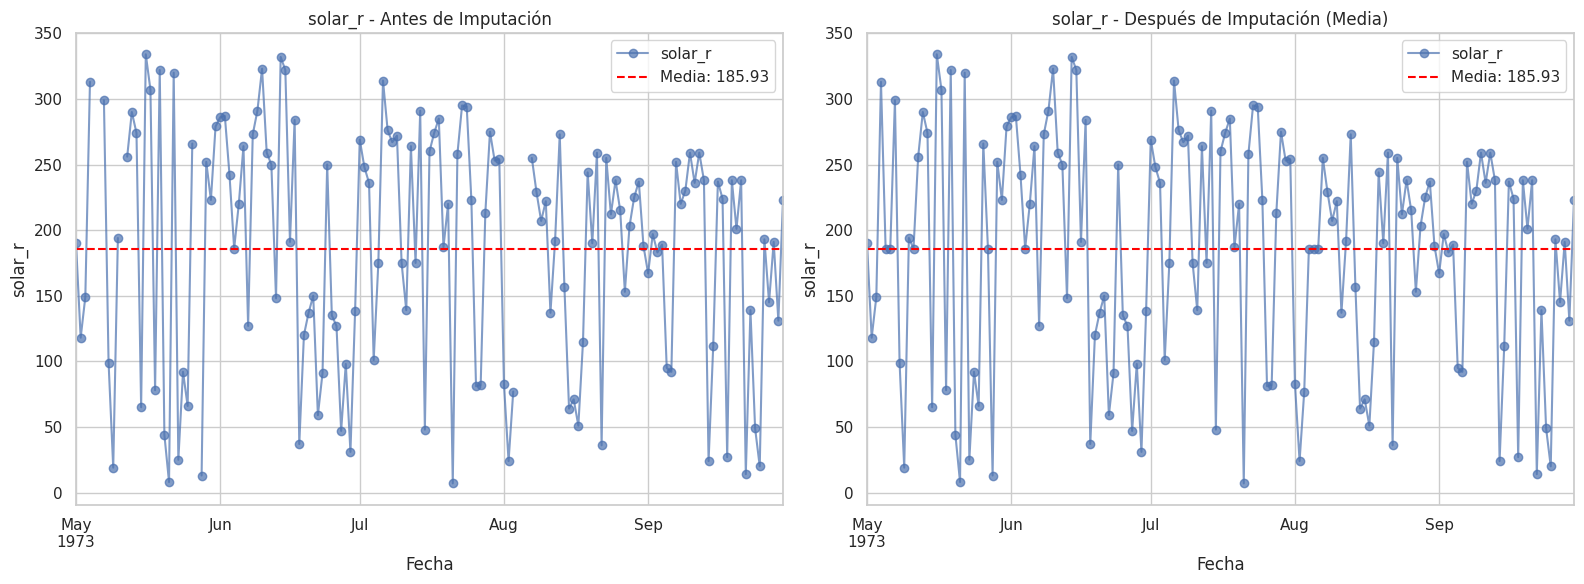

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

airquality_df['solar_r'].plot(ax=axes[0], marker='o', linestyle='-', alpha=0.7)
axes[0].set_title('solar_r - Antes de Imputación')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('solar_r')
axes[0].axhline(y=media_solar_r, color='red', linestyle='--', label=f'Media: {media_solar_r:.2f}')
axes[0].legend()

airquality_imputed_mean['solar_r'].plot(ax=axes[1], marker='o', linestyle='-', alpha=0.7)
axes[1].set_title('solar_r - Después de Imputación (Media)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('solar_r')
axes[1].axhline(y=media_solar_r, color='red', linestyle='--', label=f'Media: {media_solar_r:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## **[29]** Desarrolle un proceso de imputación de valores faltantes para la columna *ozone* usando *ffill()*

In [55]:
airquality_ffill = airquality_df.copy()
airquality_ffill['ozone'] = airquality_ffill['ozone'].ffill()
print(f'Valores faltantes en ozone después de ffill: {airquality_ffill["ozone"].isna().sum()}')

Valores faltantes en ozone después de ffill: 0


## **[30]** Desarrolle un proceso de imputación de valores faltantes para la columna *ozone* usando *bfill()*

In [56]:
airquality_bfill = airquality_df.copy()
airquality_bfill['ozone'] = airquality_bfill['ozone'].bfill()
print(f'Valores faltantes en ozone después de bfill: {airquality_bfill["ozone"].isna().sum()}')

Valores faltantes en ozone después de bfill: 0


## **[31]** Genere una gráfica lineal para los valores de la columna *ozone* del dataset.

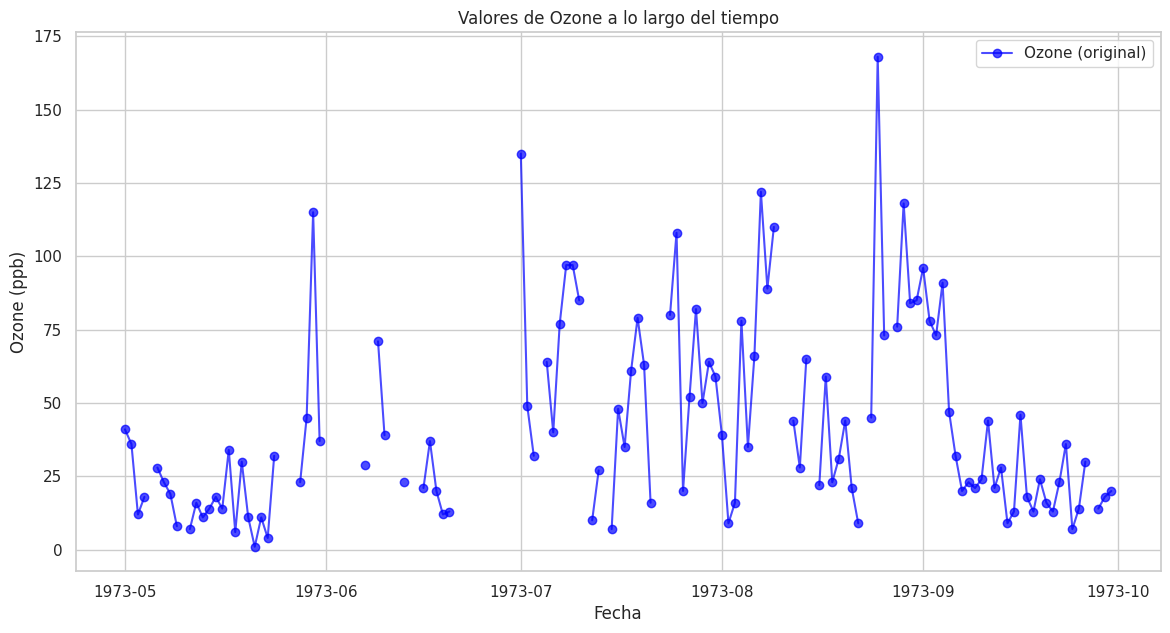

In [57]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(airquality_df.index, airquality_df['ozone'], marker='o', linestyle='-', 
        color='blue', alpha=0.7, label='Ozone (original)')
ax.set_title('Valores de Ozone a lo largo del tiempo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ozone (ppb)')
ax.legend()
ax.grid(True)
plt.show()

## **[32]** Usando la gráfica anterior simule un proceso de imputación *ffill()* y muestre cómo los valores imputados.

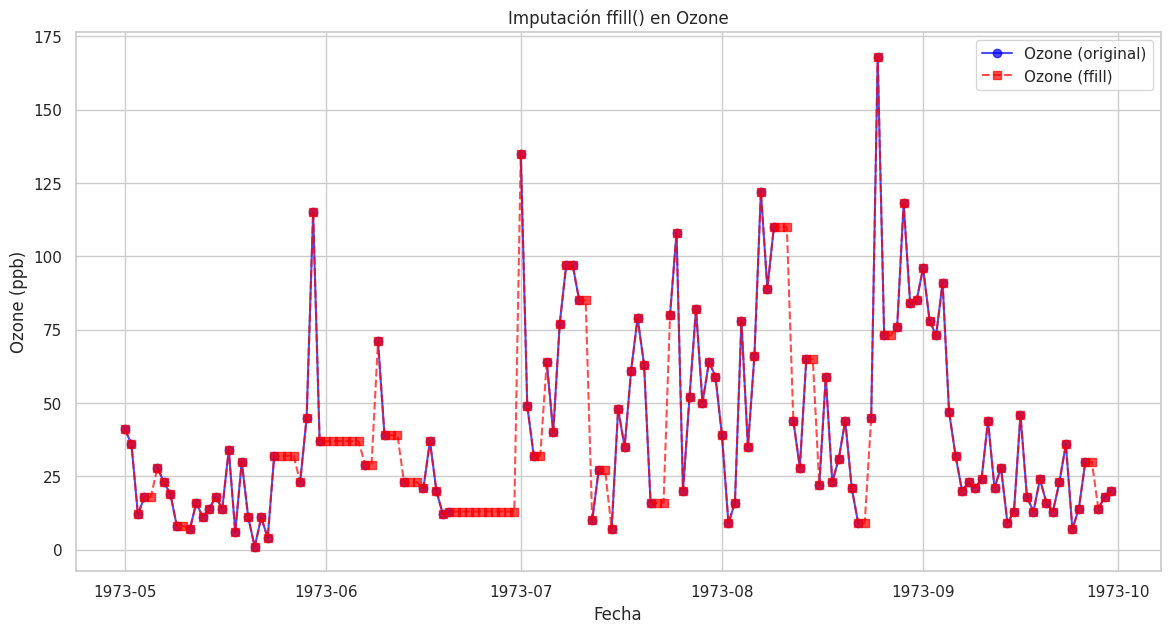

In [58]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(airquality_df.index, airquality_df['ozone'], marker='o', linestyle='-', 
        color='blue', alpha=0.7, label='Ozone (original)')
ax.plot(airquality_ffill.index, airquality_ffill['ozone'], marker='s', linestyle='--', 
        color='red', alpha=0.7, label='Ozone (ffill)')
ax.set_title('Imputación ffill() en Ozone')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ozone (ppb)')
ax.legend()
ax.grid(True)
plt.show()

## **[33]** Usando la gráfica anterior simule un proceso de imputación *bfill()* y muestre los valores imputados.

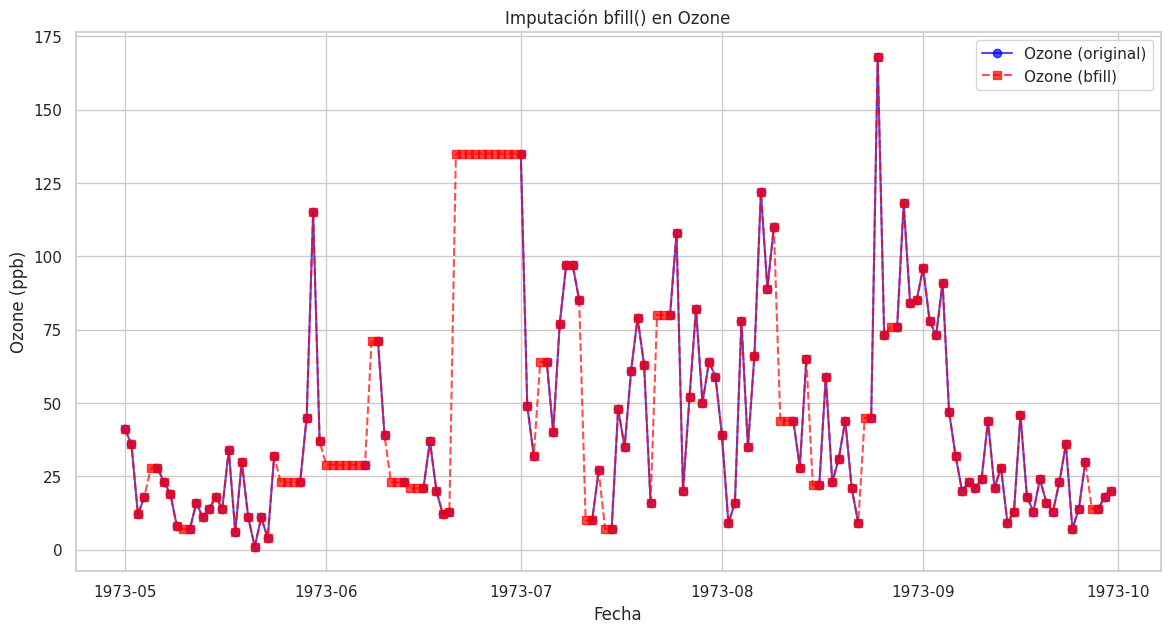

In [59]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(airquality_df.index, airquality_df['ozone'], marker='o', linestyle='-', 
        color='blue', alpha=0.7, label='Ozone (original)')
ax.plot(airquality_bfill.index, airquality_bfill['ozone'], marker='s', linestyle='--', 
        color='red', alpha=0.7, label='Ozone (bfill)')
ax.set_title('Imputación bfill() en Ozone')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ozone (ppb)')
ax.legend()
ax.grid(True)
plt.show()

## **[34]** Usando la gráfica anterior simule un proceso de imputación mediante interpolación lineal y muestre los valores imputados.

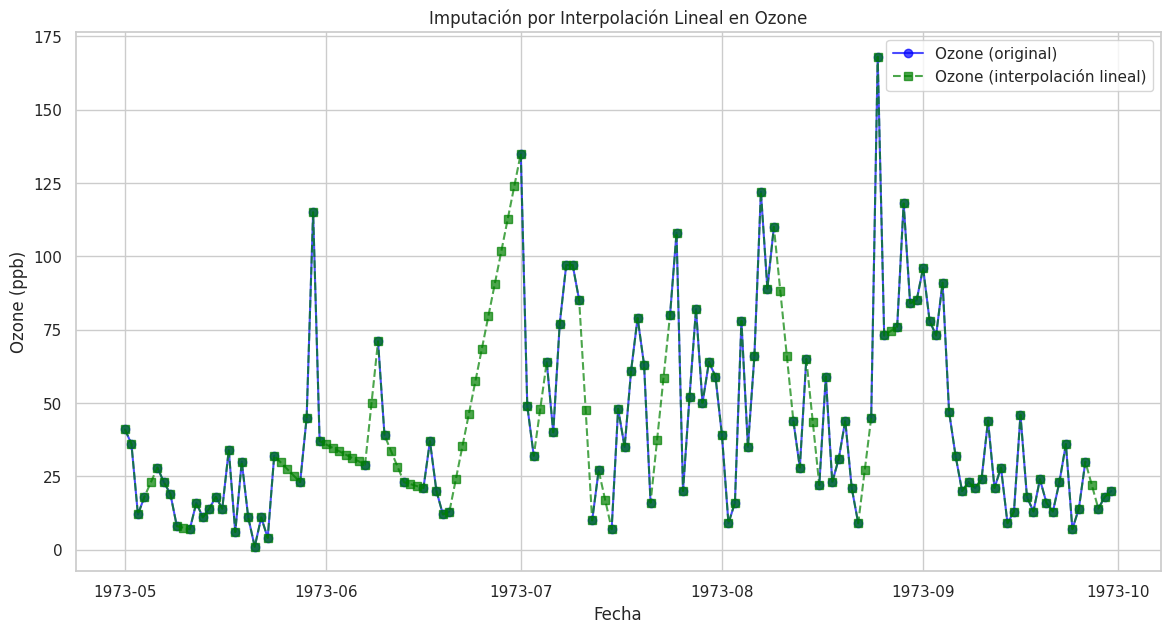

In [60]:
airquality_interp_linear = airquality_df.copy()
airquality_interp_linear['ozone'] = airquality_interp_linear['ozone'].interpolate(method='linear')

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(airquality_df.index, airquality_df['ozone'], marker='o', linestyle='-', 
        color='blue', alpha=0.7, label='Ozone (original)')
ax.plot(airquality_interp_linear.index, airquality_interp_linear['ozone'], marker='s', linestyle='--', 
        color='green', alpha=0.7, label='Ozone (interpolación lineal)')
ax.set_title('Imputación por Interpolación Lineal en Ozone')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ozone (ppb)')
ax.legend()
ax.grid(True)
plt.show()

## **[35]** Usando la gráfica anterior simule un proceso de imputación mediante interpolación cuadrática y muestre los valores imputados.

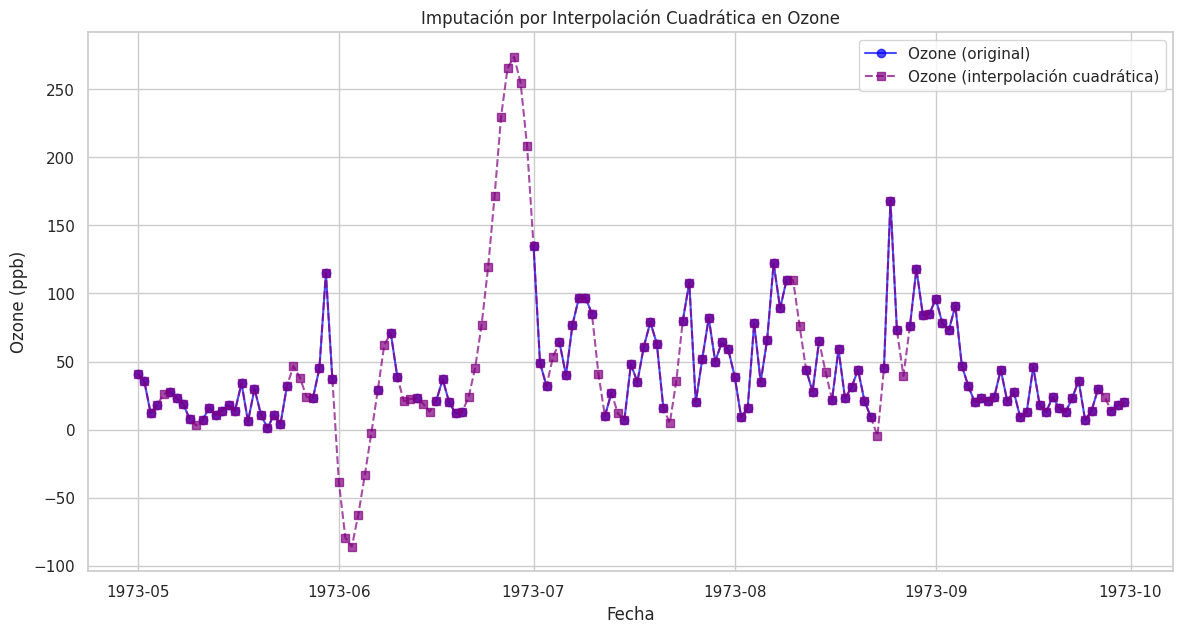

In [61]:
airquality_interp_quad = airquality_df.copy()
airquality_interp_quad['ozone'] = airquality_interp_quad['ozone'].interpolate(method='quadratic')

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(airquality_df.index, airquality_df['ozone'], marker='o', linestyle='-', 
        color='blue', alpha=0.7, label='Ozone (original)')
ax.plot(airquality_interp_quad.index, airquality_interp_quad['ozone'], marker='s', linestyle='--', 
        color='purple', alpha=0.7, label='Ozone (interpolación cuadrática)')
ax.set_title('Imputación por Interpolación Cuadrática en Ozone')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ozone (ppb)')
ax.legend()
ax.grid(True)
plt.show()

## **[36]** Desarrolle un proceso de imputación mediante KNN (Vecinos Cercanos) para las variables de *ozone* y *solar_r*. Muestre la gráfica donde indica los valores imputados, realice el proceso usando un k = 5 y k = 13

### KNN con k=5

In [62]:
df_knn = airquality_df[['ozone', 'solar_r', 'month', 'day']].copy()

imputer_knn5 = sklearn.impute.KNNImputer(n_neighbors=5)
df_knn_imp5 = pd.DataFrame(
    imputer_knn5.fit_transform(df_knn),
    columns=df_knn.columns,
    index=df_knn.index
)

print(f'Valores faltantes en ozone (k=5): {df_knn_imp5["ozone"].isna().sum()}')
print(f'Valores faltantes en solar_r (k=5): {df_knn_imp5["solar_r"].isna().sum()}')

Valores faltantes en ozone (k=5): 0
Valores faltantes en solar_r (k=5): 0


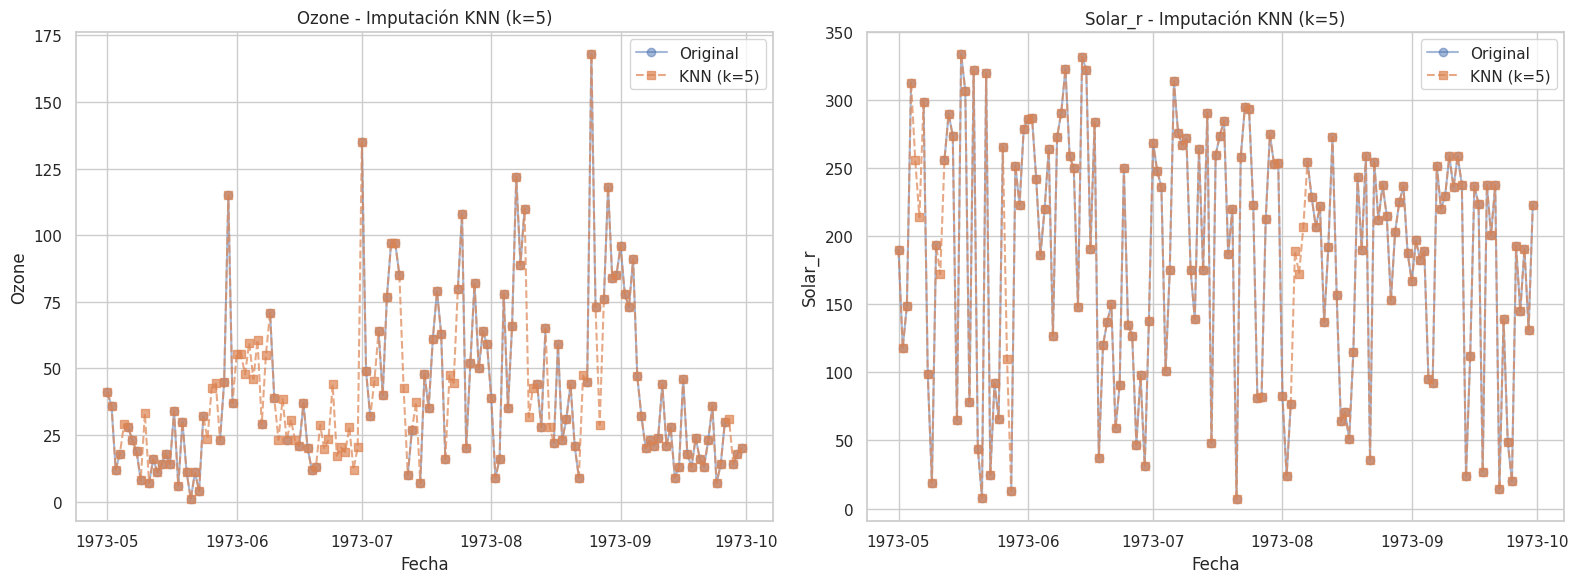

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(airquality_df.index, airquality_df['ozone'], 'o-', alpha=0.5, label='Original')
axes[0].plot(df_knn_imp5.index, df_knn_imp5['ozone'], 's--', alpha=0.7, label='KNN (k=5)')
axes[0].set_title('Ozone - Imputación KNN (k=5)')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Ozone')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(airquality_df.index, airquality_df['solar_r'], 'o-', alpha=0.5, label='Original')
axes[1].plot(df_knn_imp5.index, df_knn_imp5['solar_r'], 's--', alpha=0.7, label='KNN (k=5)')
axes[1].set_title('Solar_r - Imputación KNN (k=5)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Solar_r')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### KNN con k=13

In [64]:
imputer_knn13 = sklearn.impute.KNNImputer(n_neighbors=13)
df_knn_imp13 = pd.DataFrame(
    imputer_knn13.fit_transform(df_knn),
    columns=df_knn.columns,
    index=df_knn.index
)

print(f'Valores faltantes en ozone (k=13): {df_knn_imp13["ozone"].isna().sum()}')
print(f'Valores faltantes en solar_r (k=13): {df_knn_imp13["solar_r"].isna().sum()}')

Valores faltantes en ozone (k=13): 0
Valores faltantes en solar_r (k=13): 0


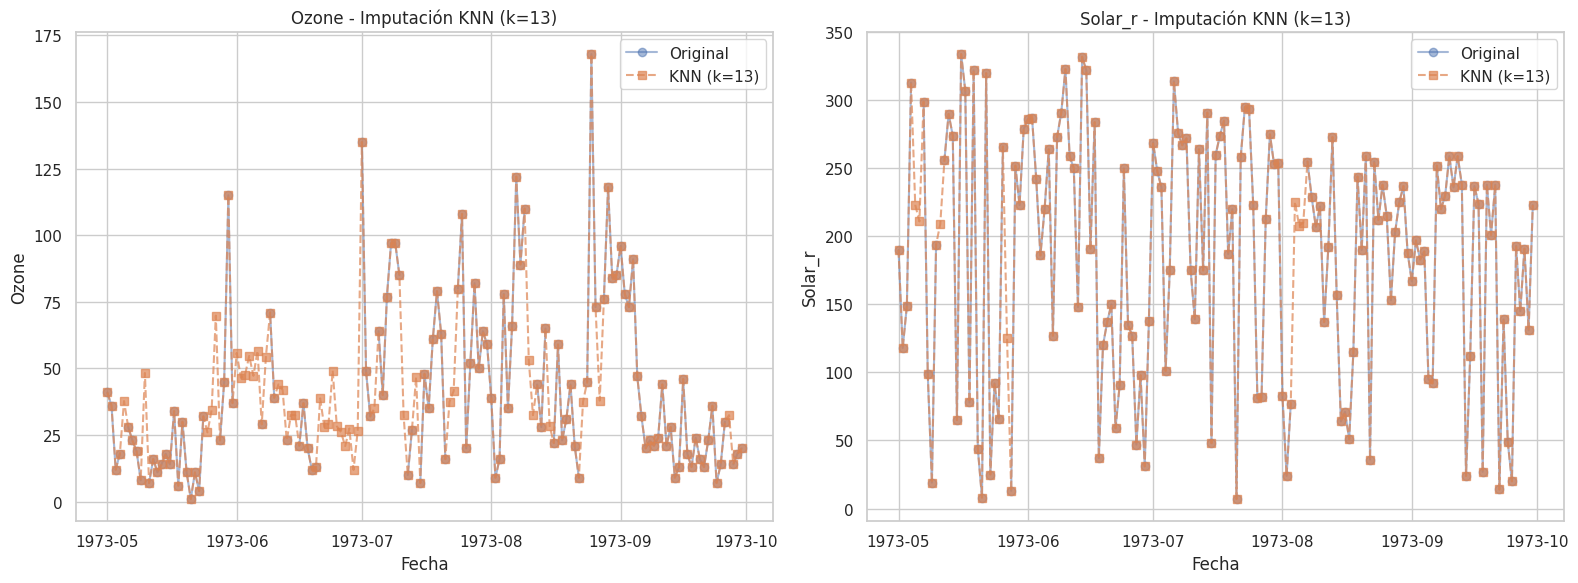

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(airquality_df.index, airquality_df['ozone'], 'o-', alpha=0.5, label='Original')
axes[0].plot(df_knn_imp13.index, df_knn_imp13['ozone'], 's--', alpha=0.7, label='KNN (k=13)')
axes[0].set_title('Ozone - Imputación KNN (k=13)')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Ozone')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(airquality_df.index, airquality_df['solar_r'], 'o-', alpha=0.5, label='Original')
axes[1].plot(df_knn_imp13.index, df_knn_imp13['solar_r'], 's--', alpha=0.7, label='KNN (k=13)')
axes[1].set_title('Solar_r - Imputación KNN (k=13)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Solar_r')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **[37]** Conclusiones

In [66]:
print('''
CONCLUSIONES
════════════

1. En la Parte 1 se exploraron las relaciones entre variables del dataset de pingüinos.
   Se visualizaron distribuciones mediante histogramas, jointplots, PMFs y ECDFs,
   y se construyeron modelos de regresión lineal para predecir body_mass_g.
   El mejor modelo (Modelo 5) incluyó bill_depth_mm, flipper_length_mm, bill_length_mm
   y la isla como variable categórica, logrando un R² superior a 0.85.
   La regresión logística multinomial clasificó las 3 especies con alta precisión.

2. En la Parte 2 se analizaron los valores faltantes del dataset riskfactors utilizando
   la extensión .missing de pandas. Se identificaron las variables con más valores
   ausentes y se visualizaron patrones de faltantes mediante matrices, barras y
   upsetplots. La correlación de nulidad mostró relaciones entre variables con
   patrones de ausencia similares. La eliminación listwise redujo significativamente
   el número de instancias.

3. En la Parte 3 se aplicaron diversas técnicas de imputación sobre el dataset
   AirQuality: imputación por media, forward-fill (ffill), backward-fill (bfill),
   interpolación lineal, interpolación cuadrática y KNN con k=5 y k=13.
   Cada método tiene ventajas según la naturaleza de los datos:
   - ffill/bfill son útiles para series temporales con valores faltantes consecutivos.
   - La interpolación (lineal/cuadrática) captura tendencias subyacentes.
   - KNN aprovecha la similitud entre instancias para estimar valores faltantes.
   - La imputación por media es simple pero puede reducir la variabilidad.

4. La correcta gestión de valores faltantes es crucial para evitar sesgos en los
   análisis y modelos. La elección del método de imputación debe considerar el
   patrón de ausencia, el tipo de variable y el objetivo del análisis.
''')


CONCLUSIONES
════════════

1. En la Parte 1 se exploraron las relaciones entre variables del dataset de pingüinos.
   Se visualizaron distribuciones mediante histogramas, jointplots, PMFs y ECDFs,
   y se construyeron modelos de regresión lineal para predecir body_mass_g.
   El mejor modelo (Modelo 5) incluyó bill_depth_mm, flipper_length_mm, bill_length_mm
   y la isla como variable categórica, logrando un R² superior a 0.85.
   La regresión logística multinomial clasificó las 3 especies con alta precisión.

2. En la Parte 2 se analizaron los valores faltantes del dataset riskfactors utilizando
   la extensión .missing de pandas. Se identificaron las variables con más valores
   ausentes y se visualizaron patrones de faltantes mediante matrices, barras y
   upsetplots. La correlación de nulidad mostró relaciones entre variables con
   patrones de ausencia similares. La eliminación listwise redujo significativamente
   el número de instancias.

3. En la Parte 3 se aplicaron diversas t